# Setup

In [1]:
# Standard library imports
import os
import time
import warnings

# The Keras backend must be chosen BEFORE keras is imported
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Third-party imports: modeling
import torch
import keras

# Third-party imports: the foundation models
import timesfm
from tirex2 import TimeseriesType, load_model
from chronos import BaseChronosPipeline

# Configuration & Settings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())

/Users/kbanachewicz/Documents/time-series-with-Konrad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keras version: 3.15.0
Keras backend: torch


This section of code prepares the environment for time series forecasting using several Python libraries. It begins by importing necessary modules from both the standard library – such as `os`, `time`, and `warnings` – and various third-party packages. 

The line `os.environ['KERAS_BACKEND'] = 'torch'` is crucial; it explicitly sets the Keras backend to PyTorch *before* the Keras library itself is imported. This ensures that Keras will utilize PyTorch for its underlying tensor operations, which can be important for performance and compatibility with other libraries.

Following this, core data science tools like `numpy` (for numerical computation), `pandas` (for data manipulation), and `matplotlib` (for plotting) are imported.  Then come the modeling-specific imports: `torch` itself, and `keras`. 

The code then brings in specialized time series libraries: `timesfm`, `tirex2`, and `chronos`. These packages provide functionalities for building and deploying time series models, including loading pre-trained models (`load_model` from `tirex2`) and defining forecasting pipelines (`BaseChronosPipeline` from `chronos`).

Finally, the code suppresses warning messages related to future deprecations using `warnings.simplefilter` and general warnings with `warnings.filterwarnings`. This keeps the output cleaner during execution. The last two lines print the versions of Keras and its currently selected backend (PyTorch) to confirm the setup.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    STORE = 1                          # the store whose items we forecast
    HERO_ITEM = 1                      # the single series used for close-ups
    ARENA_ITEMS = list(range(1, 11))   # ten series for the head-to-head
    HORIZON = 14                       # forecast two weeks ahead
    LOOKBACK = 84                      # window length for models we train ourselves
    CONTEXT = 512                      # history handed to the foundation models
    N_ORIGINS = 12                     # weekly walk-forward test origins
    QUANTILES = [0.1, 0.5, 0.9]        # quantile levels for probabilistic scoring

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

# hardware: Apple GPU if present, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print("Computing on:", DEVICE)

Computing on: mps


This code defines configuration settings and prepares the plotting environment for a time series forecasting project. 

A class named `CFG` is created to hold various parameters related to data handling, model training, and evaluation. These include paths to data (`data_folder`) and graph storage (`graph_folder`), dimensions for image-based visualizations (`img_dim1`, `img_dim2`), a random seed for reproducibility (`SEED`), identifiers for specific items being forecast (`STORE`, `HERO_ITEM`, `ARENA_ITEMS`), the forecasting horizon (`HORIZON`), lengths of input windows for models (`LOOKBACK`, `CONTEXT`), the number of walk-forward validation origins (`N_ORIGINS`), and the quantile levels to be used in probabilistic forecasts (`QUANTILES`).

Next, the plotting style is set using Matplotlib’s `seaborn-v0_8` theme, and a default figure size is defined based on the dimensions specified in `CFG`. The random number generator for NumPy is seeded with the value from `CFG.SEED` to ensure consistent results across runs.

Finally, the code determines the computational device to be used – either Apple’s Metal Performance Shaders (MPS) GPU if available, or the CPU otherwise. A message indicating which device will be utilized is printed to the console. This ensures that the code can run efficiently on machines with compatible GPUs while still functioning correctly on systems without them.

# Utils

In [3]:
def forecast_metrics(actual, predicted):
    """Point-forecast accuracy: MAE and RMSE, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    return {'mae': round(float(mae), 2), 'rmse': round(float(rmse), 2)}

This code defines a function called `forecast_metrics` that calculates and returns common accuracy metrics for evaluating time series forecasts.

The function takes two arguments: `actual`, representing the true values, and `predicted`, representing the forecasted values. It first converts both inputs into NumPy arrays with a floating-point data type to ensure accurate calculations. 

Then, it computes the Mean Absolute Error (MAE) – the average absolute difference between actual and predicted values – and the Root Mean Squared Error (RMSE) – the square root of the average squared difference between actual and predicted values. Both metrics quantify the magnitude of forecast errors.

Finally, the function returns a dictionary containing the calculated MAE and RMSE values, rounded to two decimal places for easier readability and display. This provides a concise summary of forecast accuracy.

In [4]:
def pinball_loss(actual, quantile_forecast, tau):
    """Score a single quantile forecast at level tau (lower is better)."""
    actual = np.asarray(actual, dtype=float)
    quantile_forecast = np.asarray(quantile_forecast, dtype=float)
    diff = actual - quantile_forecast
    return float(np.mean(np.maximum(tau * diff, (tau - 1) * diff)))


def interval_coverage(actual, lower, upper):
    """Fraction of actual values that fall inside [lower, upper]."""
    actual = np.asarray(actual, dtype=float)
    inside = (actual >= np.asarray(lower, dtype=float)) & \
             (actual <= np.asarray(upper, dtype=float))
    return float(np.mean(inside))

This code defines two functions for evaluating probabilistic time series forecasts – `pinball_loss` and `interval_coverage`.

The `pinball_loss` function calculates the pinball loss (also known as quantile loss) for a single quantile forecast. It takes three arguments: `actual`, the true value; `quantile_forecast`, the predicted value at a specific quantile level; and `tau`, the quantile level itself (a value between 0 and 1). The function converts both input arrays to floating-point type. It then computes the difference between the actual and forecasted values, and returns the mean of the maximum of two expressions involving this difference and the quantile level `tau`. This loss function is asymmetric and penalizes underestimation and overestimation differently based on `tau`, making it suitable for evaluating quantile forecasts.

The `interval_coverage` function determines the fraction of actual values that fall within a specified prediction interval. It takes three arguments: `actual`, the true values; `lower`, the lower bound of the prediction interval; and `upper`, the upper bound of the prediction interval. The inputs are converted to NumPy arrays with floating-point data types.  It creates a boolean array `inside` indicating whether each actual value falls between the lower and upper bounds. Finally, it returns the mean of this boolean array, which represents the proportion of actual values covered by the prediction interval. This metric assesses the calibration of probabilistic forecasts – how well the predicted intervals contain the true values.

In [5]:
def make_windows(series_z, lookback, horizon):
    """Slide a (lookback -> horizon) window over a 1-D array."""
    X, Y = [], []
    for i in range(len(series_z) - lookback - horizon + 1):
        X.append(series_z[i:i + lookback])
        Y.append(series_z[i + lookback:i + lookback + horizon])
    return np.array(X), np.array(Y)

This code defines a function called `make_windows` that prepares time series data for supervised learning by creating input-output pairs (windows).

The function takes three arguments: `series_z`, the one-dimensional time series array; `lookback`, the length of the input window (the number of past values used to predict future values); and `horizon`, the length of the output horizon (the number of future values to be predicted). 

It initializes two empty lists, `X` and `Y`. The code then iterates through the time series using a sliding window approach. In each iteration, it extracts a segment of length `lookback` from the input series as the input (`X`) and a subsequent segment of length `horizon` as the target output (`Y`).  The loop continues until it reaches a point where extracting both windows would exceed the bounds of the time series.

Finally, the function converts the lists `X` and `Y` into NumPy arrays and returns them. The resulting `X` array contains all the input windows, and the `Y` array contains the corresponding target values for each window. This format is suitable for training supervised learning models on time series data.

In [6]:
def context_for(item, origin, n_days):
    """The last n_days of an item's history strictly BEFORE origin."""
    history = panel[item].loc[:origin - pd.Timedelta(days=1)]
    return history.to_numpy()[-n_days:]


def actuals_for(item, origin):
    """The HORIZON true values of an item, starting AT origin."""
    window = panel[item].loc[origin:origin + pd.Timedelta(days=CFG.HORIZON - 1)]
    return window.to_numpy()

These two functions are designed to extract specific portions of a time series dataset for forecasting and evaluation. They operate on a presumed data structure called `panel`, which likely represents a multi-dimensional time series dataset indexed by items and dates.

The `context_for` function retrieves the historical context needed as input for a forecast. It takes three arguments: `item`, identifying the specific time series; `origin`, representing the starting date for the forecast; and `n_days`, specifying the number of past days to include in the context. The function selects all data for the given `item` up to, but not including, the `origin` date using `.loc[:origin - pd.Timedelta(days=1)]`. It then extracts the last `n_days` from this historical data and returns it as a NumPy array. This provides the model with recent history before the forecast origin.

The `actuals_for` function retrieves the true values corresponding to the forecasting horizon for evaluation purposes. It takes two arguments: `item`, identifying the time series, and `origin`, the starting date of the forecast horizon. The function selects data for the given `item` from the `origin` date up to `CFG.HORIZON - 1` days after the origin using `.loc[origin:origin + pd.Timedelta(days=CFG.HORIZON - 1)]`. It then converts this selection into a NumPy array and returns it, representing the actual values that will be compared against the model’s predictions.

In [7]:
def plot_forecast(item, origin, forecast, title,
                  lower=None, upper=None, history_days=90):
    """History tail + actuals + forecast, with an optional 80% band."""
    history = panel[item].loc[:origin - pd.Timedelta(days=1)].tail(history_days)
    test_index = pd.date_range(origin, periods=CFG.HORIZON, freq='D')
    actual = panel[item].loc[test_index]

    plt.figure()
    plt.plot(history.index, history.values, linewidth=2, label='History')
    plt.plot(test_index, actual.values, linewidth=2,
             color='black', label='Actual')
    plt.plot(test_index, forecast, 'g--', marker='o', label='Forecast')
    if lower is not None:
        plt.fill_between(test_index, lower, upper, color='coral',
                         alpha=0.3, label='80% interval')
    plt.title(title)
    plt.legend()
    plt.xlabel("")
    plt.show()

This code defines a function called `plot_forecast` that visualizes time series forecasts alongside historical data and actual values.

The function takes several arguments: `item`, identifying the time series; `origin`, the starting date of the forecast horizon; `forecast`, the predicted values for the forecasting horizon; `title`, a string for the plot title; optional `lower` and `upper` bounds defining a prediction interval; and `history_days`, specifying how many days of historical data to display.

It first retrieves the recent history of the time series, selecting the last `history_days` from the `panel` up to (but not including) the forecast origin date. It then creates a date range (`test_index`) covering the forecasting horizon starting at the `origin` date. The actual values for this period are extracted from the `panel`.

The function then generates a plot using Matplotlib. It plots the historical data, the actual values during the forecast horizon, and the forecasted values as separate lines with distinct styles and labels. If `lower` and `upper` bounds are provided, it fills the area between them with a semi-transparent coral color to represent a prediction interval. The plot is titled using the provided `title`, includes a legend for clarity, removes the x-axis label, and displays the resulting visualization. This provides a comprehensive visual assessment of forecast performance by comparing predictions against historical trends and actual outcomes.

# Groundwork

In [8]:
raw = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])
store = raw[raw['store'] == CFG.STORE]
panel = store.pivot(index='date', columns='item', values='sales').asfreq('D')

print("Panel shape:", panel.shape)
print("Date range:", panel.index.min().date(), "to", panel.index.max().date())
print("Missing days:", int(panel.isna().sum().sum()))
panel.head(3)

Panel shape: (1826, 50)
Date range: 2013-01-01 to 2017-12-31
Missing days: 0


item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13,33,15,10,11,31,25,33,18,37,...,6,21,22,20,37,30,17,21,18,30
2013-01-02,11,43,30,11,6,36,23,37,23,34,...,15,24,27,15,40,30,15,26,10,32
2013-01-03,14,23,14,8,8,18,34,38,25,32,...,5,14,19,11,42,30,5,25,17,25


This code loads, preprocesses, and summarizes a time series dataset from a CSV file.

It begins by reading the data from the file specified by `CFG.data_folder + 'train.csv'` using `pd.read_csv`. The `parse_dates=['date']` argument ensures that the 'date' column is correctly interpreted as datetime objects. 

Next, it filters the data to include only records for a specific store, identified by `CFG.STORE`. This creates a subset of the data relevant to the forecasting task.

The core transformation step involves reshaping the data into a panel format using `pivot`. The `pivot` function transforms the data so that dates become the index, items (products or SKUs) become columns, and sales values fill the cells.  The `.asfreq('D')` part ensures that there is one entry for each day in the dataset; any missing days are filled with NaN (Not a Number) values. This creates a time series panel where each row represents a date and each column represents an item's daily sales.

Finally, the code prints summary statistics about the resulting `panel`: its shape (number of dates x number of items), the range of dates covered by the data, and the total number of missing values (NaNs). The `.head(3)` displays the first three rows of the panel to give a quick glimpse of the data structure. This provides an overview of the dataset's dimensions, temporal coverage, and completeness before proceeding with further analysis or modeling.

Mean daily sales: 19.97 | min: 4 | max: 50


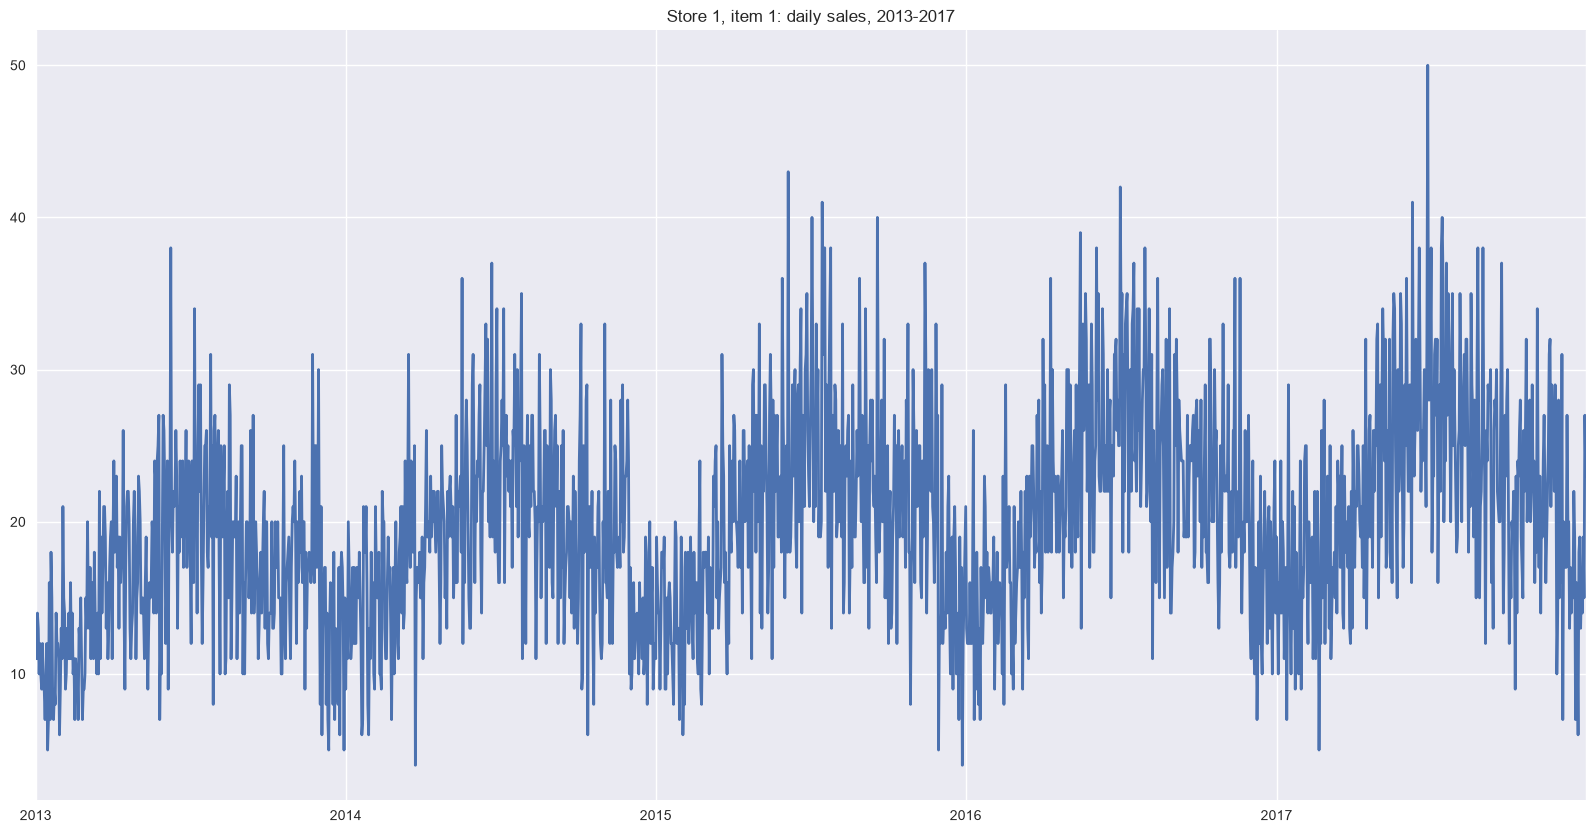

In [9]:
hero = panel[CFG.HERO_ITEM]
hero.plot(linewidth=2, xlabel="",
          title=f"Store {CFG.STORE}, item {CFG.HERO_ITEM}: daily sales, 2013-2017")
print(f"Mean daily sales: {hero.mean():.2f} | min: {hero.min()} | max: {hero.max()}")

This code focuses on visualizing and summarizing the time series data for a specific "hero" item.

It first selects the time series corresponding to the `HERO_ITEM` from the `panel`, assigning it to the variable `hero`. 

Then, it generates a line plot of this time series using Matplotlib’s `.plot()` method. The plot displays daily sales over time with a linewidth of 2, removes the x-axis label for cleaner presentation, and sets a descriptive title indicating the store number, item number, and date range.

Finally, it calculates and prints summary statistics for the `hero` item's sales: the mean (average) daily sales formatted to two decimal places, the minimum sales value, and the maximum sales value. This provides insights into the typical sales level and the range of variation for this particular item.

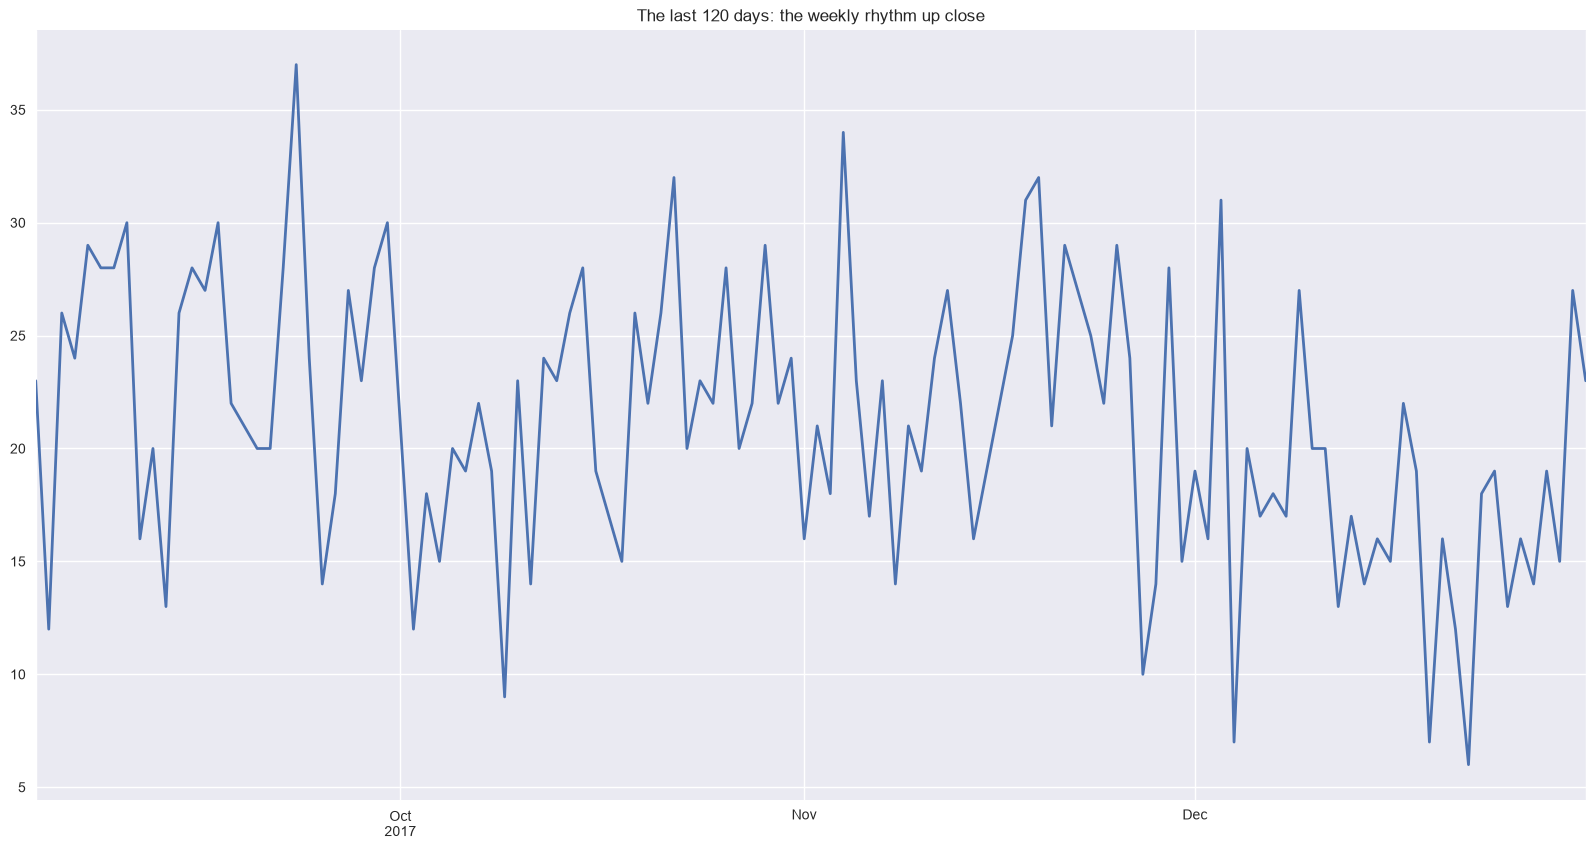

In [10]:
hero.tail(120).plot(linewidth=2, xlabel="",
                    title="The last 120 days: the weekly rhythm up close")
plt.show()

This code displays a zoomed-in view of the time series data for the "hero" item, focusing on the most recent 120 days to highlight any recurring patterns.

It selects the last 120 data points from the `hero` time series using `.tail(120)`. Then, it generates a line plot of these values using Matplotlib’s `.plot()` method. The plot has a linewidth of 2 and removes the x-axis label for clarity. A title is added to indicate that the plot shows the last 120 days and aims to reveal any weekly rhythms or patterns in the data.

Finally, `plt.show()` displays the generated plot. This allows visual inspection of short-term trends and seasonality within the hero item’s sales data.

In [11]:
SPLIT_DATE = pd.Timestamp('2017-10-01')
origins = pd.date_range(SPLIT_DATE, periods=CFG.N_ORIGINS, freq='7D')
train_panel = panel[panel.index < SPLIT_DATE]

print("Training days per series:", len(train_panel))
print("First origin:", origins[0].date(), "| last origin:", origins[-1].date())
print("Last forecast day:", (origins[-1] + pd.Timedelta(days=CFG.HORIZON - 1)).date())

Training days per series: 1734
First origin: 2017-10-01 | last origin: 2017-12-17
Last forecast day: 2017-12-30


This code sets up the data splitting and defines the time points for walk-forward validation.

It first establishes a `SPLIT_DATE` of October 1, 2017, which marks the boundary between training and testing data. Then, it generates a sequence of dates called `origins` using `pd.date_range`. These dates represent the starting points for each walk-forward validation fold. The sequence starts at `SPLIT_DATE`, has a length equal to `CFG.N_ORIGINS` (number of origins), and increments by 7 days (`freq='7D'`), creating weekly test sets.

Next, it creates a training panel called `train_panel` by selecting all data from the original `panel` where the date is strictly before the `SPLIT_DATE`. This ensures that the model is trained only on historical data and does not have access to future information during training. 

Finally, the code prints several summary statistics: the number of days in the training dataset for each time series; the first and last dates in the `origins` sequence; and the date representing the end of the forecast horizon for the final validation fold (calculated by adding `CFG.HORIZON - 1` days to the last origin). This provides a clear overview of the data splitting strategy and the timeline for walk-forward validation.

In [12]:
origin0 = origins[0]
actual0 = actuals_for(CFG.HERO_ITEM, origin0)
context0 = context_for(CFG.HERO_ITEM, origin0, CFG.CONTEXT)

# repeat the last observed value for 14 days
naive_forecast = np.repeat(context0[-1], CFG.HORIZON)
# repeat the last observed week, twice
snaive_forecast = np.tile(context0[-7:], 3)[:CFG.HORIZON]

print("Naive:         ", forecast_metrics(actual0, naive_forecast))
print("Seasonal naive:", forecast_metrics(actual0, snaive_forecast))

Naive:          {'mae': 11.07, 'rmse': 12.03}
Seasonal naive: {'mae': 5.36, 'rmse': 6.53}


This code evaluates the performance of two simple baseline forecasting methods – a naive forecast and a seasonal naive forecast – on the first validation origin.

It begins by selecting the first date from the `origins` sequence and assigning it to `origin0`. Then, it uses the previously defined functions `actuals_for` and `context_for` to retrieve the actual values for the hero item during the forecasting horizon starting at `origin0`, and the historical context leading up to that point.

Next, it generates two baseline forecasts:
*   **Naive forecast:** This simply repeats the last observed value from the context `CFG.HORIZON` times, assuming that future values will be the same as the most recent one.
*   **Seasonal naive forecast:** This repeats the last observed week (7 days) twice and then truncates to the length of the forecasting horizon (`CFG.HORIZON`). It assumes that future values will follow the pattern of the previous week.

Finally, it evaluates the accuracy of both forecasts using the `forecast_metrics` function, which calculates MAE and RMSE. The results are printed to the console, providing a benchmark against which more sophisticated forecasting models can be compared. This establishes a baseline level of performance for the dataset and task.

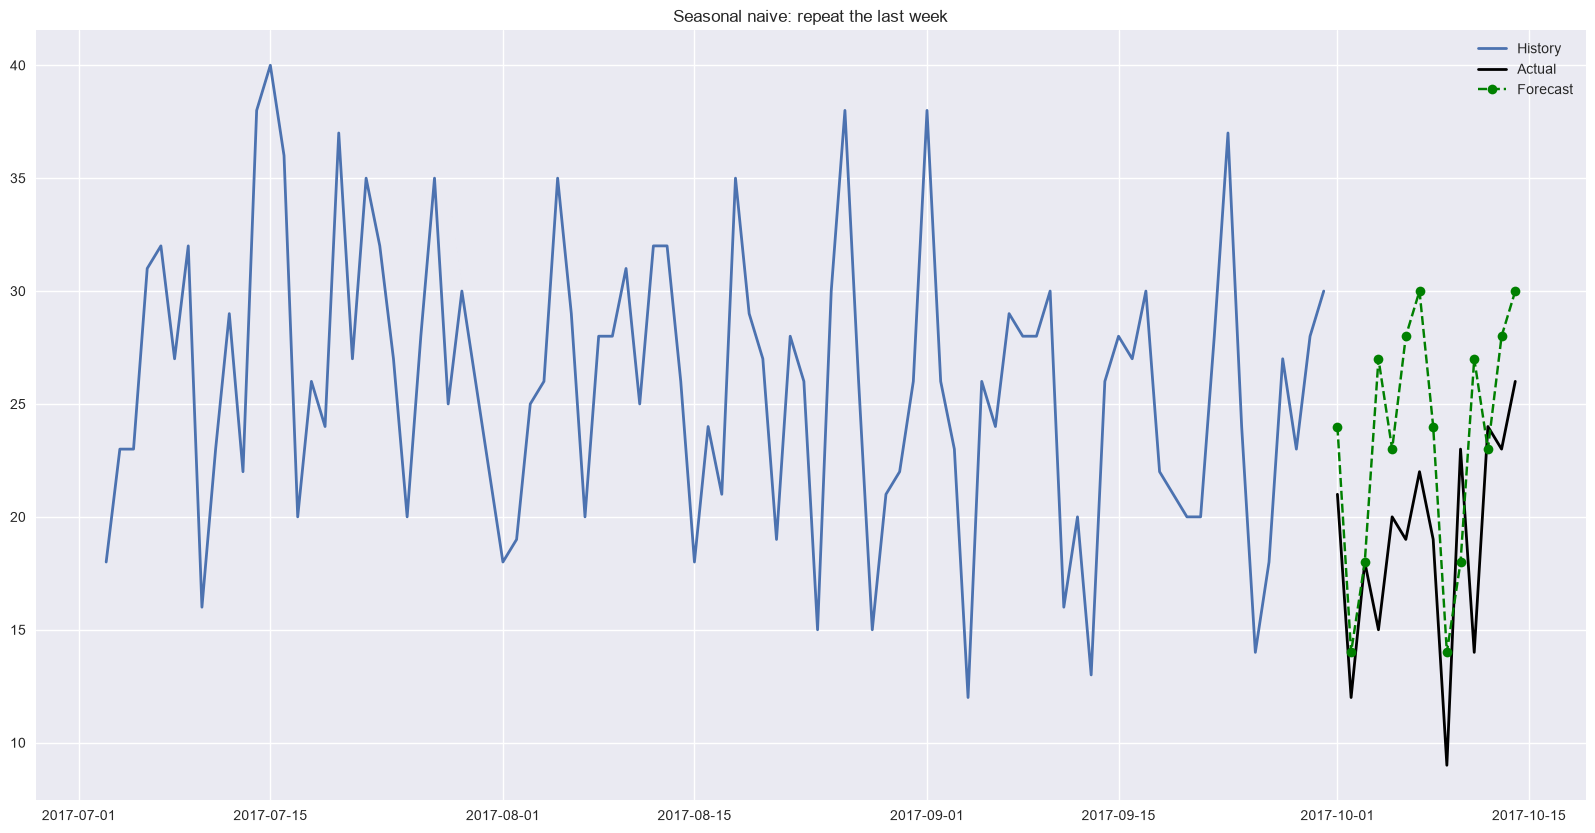

In [13]:
plot_forecast(CFG.HERO_ITEM, origin0, snaive_forecast,
              "Seasonal naive: repeat the last week")

This code generates a visualization of the seasonal naive forecast for the hero item at the first validation origin.

It calls the `plot_forecast` function with the following arguments: `CFG.HERO_ITEM`, identifying the time series; `origin0`, the starting date of the forecast horizon; `snaive_forecast`, the predicted values generated by the seasonal naive method; and a title indicating that the plot shows the results of repeating the last week's data.

The `plot_forecast` function then creates a line plot displaying the historical data, actual values during the forecasting horizon, and the seasonal naive forecast, along with any optional prediction intervals. This allows for visual assessment of how well the seasonal naive method captures the underlying patterns in the hero item’s sales data at this specific point in time.

# The specialist paradigm: TYOM


## A linear forecaster

In [14]:
train_stats = {item: (float(train_panel[item].mean()), float(train_panel[item].std()))
               for item in CFG.ARENA_ITEMS}

X_list, Y_list = [], []
for item in CFG.ARENA_ITEMS:
    mean, std = train_stats[item]
    z = (train_panel[item].to_numpy() - mean) / std
    X_item, Y_item = make_windows(z, CFG.LOOKBACK, CFG.HORIZON)
    X_list.append(X_item)
    Y_list.append(Y_item)

X_all = np.concatenate(X_list).astype('float32')
Y_all = np.concatenate(Y_list).astype('float32')

# hold out the most recent 10% of each item's windows for validation
offsets = np.cumsum([0] + [len(x) for x in X_list[:-1]])
val_idx = np.concatenate([np.arange(len(x))[-int(0.1 * len(x)):] + off
                          for x, off in zip(X_list, offsets)])
val_mask = np.zeros(len(X_all), dtype=bool)
val_mask[val_idx] = True
X_train, Y_train = X_all[~val_mask], Y_all[~val_mask]
X_val, Y_val = X_all[val_mask], Y_all[val_mask]

print("Training windows:", X_train.shape, "| validation windows:", X_val.shape)

Training windows: (14740, 84) | validation windows: (1630, 84)


This code prepares the training and validation data for a time series forecasting model using standardization and windowing techniques. It focuses on the items specified in `CFG.ARENA_ITEMS`.

First, it calculates the mean and standard deviation of each item’s sales in the training panel (`train_panel`) and stores them in the `train_stats` dictionary. This information will be used for standardization.

Then, it iterates through each item in `CFG.ARENA_ITEMS`. For each item, it standardizes the time series data by subtracting the mean and dividing by the standard deviation (z-score normalization). It then uses the `make_windows` function to create input-output pairs (windows) with a lookback of `CFG.LOOKBACK` and a horizon of `CFG.HORIZON`. The resulting windows for each item are appended to the `X_list` (inputs) and `Y_list` (targets).

Next, it concatenates all the input windows in `X_list` into a single array `X_all` and similarly concatenates all the target windows in `Y_list` into `Y_all`. The data type of both arrays is set to 'float32'.

To create a validation set, it calculates offsets for each item’s windows within the concatenated arrays. It then selects the last 10% of the windows for each item as the validation set (`val_idx`). A boolean mask `val_mask` is created to identify the indices belonging to the validation set. Finally, it splits the combined input and target arrays into training sets (`X_train`, `Y_train`) and validation sets (`X_val`, `Y_val`) based on this mask.

Finally, it prints the shapes of the training and validation window datasets, providing a summary of the data split. This prepares the data in a format suitable for training and evaluating machine learning models for time series forecasting. The standardization step ensures that all items are on a comparable scale, while the windowing creates the input-output pairs needed for supervised learning.

In [15]:
keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    linear_model = keras.Sequential([
        keras.layers.Input((CFG.LOOKBACK,)),
        keras.layers.Dense(CFG.HORIZON)
    ])
linear_model.compile(optimizer='adam', loss='mse')

start = time.time()
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history_linear = linear_model.fit(X_train, Y_train,
                                  validation_data=(X_val, Y_val),
                                  epochs=50, batch_size=256,
                                  callbacks=[early_stop], verbose=0)
linear_train_time = time.time() - start

print(f"Parameters: {linear_model.count_params():,}")
print(f"Training: {linear_train_time:.1f}s"
      f" ({len(history_linear.history['loss'])} epochs)")

Parameters: 1,190
Training: 4.3s (28 epochs)


This code defines, compiles, and trains a simple linear model using Keras for time series forecasting.

It first sets the random seed for Keras to ensure reproducibility using `keras.utils.set_random_seed(CFG.SEED)`. Then, it uses a context manager (`with keras.device(DEVICE):`) to specify the computational device (CPU or GPU) on which the model will be built and trained.

A sequential neural network called `linear_model` is created. It consists of an input layer that accepts sequences of length `CFG.LOOKBACK`, followed by a single dense (fully connected) layer with `CFG.HORIZON` output units. This represents a simple linear regression model applied to the time series data.

The model is compiled using the 'adam' optimizer and Mean Squared Error ('mse') as the loss function, which are appropriate for regression tasks.

Next, the code measures the training time. An `EarlyStopping` callback is configured with a patience of 5 epochs (stopping if validation loss doesn’t improve for 5 consecutive epochs) and set to restore the best weights encountered during training. The model is then trained using the `fit` method on the training data (`X_train`, `Y_train`), with validation performed on the validation data (`X_val`, `Y_val`). Training runs for a maximum of 50 epochs with a batch size of 256, and the early stopping callback is used to prevent overfitting. The `verbose=0` argument suppresses output during training.

Finally, it calculates and prints the total number of parameters in the model using `linear_model.count_params()`, as well as the training time and the actual number of epochs trained (determined by the early stopping mechanism). This provides information about the model’s complexity and training efficiency.

In [16]:
def forecast_all_origins(model, needs_3d=False):
    """Forecast every (origin, item) pair with a trained window model."""
    contexts, keys = [], []
    for origin in origins:
        for item in CFG.ARENA_ITEMS:
            mean, std = train_stats[item]
            z_context = (context_for(item, origin, CFG.LOOKBACK) - mean) / std
            contexts.append(z_context)
            keys.append((origin, item))

    batch = np.array(contexts, dtype='float32')
    if needs_3d:
        batch = batch[..., None]
    predictions = model.predict(batch, verbose=0)

    forecasts = {}
    for key, pred in zip(keys, predictions):
        mean, std = train_stats[key[1]]
        forecasts[key] = pred * std + mean
    return forecasts

This code defines a function called `forecast_all_origins` that generates forecasts for all combinations of validation origins and items using a trained model.

The function takes two arguments: `model`, the trained Keras model; and `needs_3d`, a boolean flag indicating whether the model expects 3D input (which is not used in this specific code).

It initializes empty lists called `contexts` and `keys`. It then iterates through each origin in the `origins` sequence and each item in `CFG.ARENA_ITEMS`. For each combination, it retrieves the historical context for that item at that origin using `context_for`, standardizes the context data using the pre-calculated mean and standard deviation from `train_stats`, and appends both the standardized context and a tuple representing the (origin, item) pair to their respective lists.

Next, it converts the list of contexts into a NumPy array called `batch` with a data type of 'float32'. If `needs_3d` is True, it reshapes the batch to add an extra dimension; however, this reshaping isn't actually performed in the current code. The model then predicts future values for each context using `model.predict`, suppressing output during prediction (`verbose=0`).

Finally, it creates a dictionary called `forecasts`. It iterates through the predicted values and their corresponding (origin, item) keys. For each pair, it de-standardizes the prediction by multiplying it by the standard deviation and adding the mean for that item (obtained from `train_stats`), effectively converting the forecast back to the original sales scale. The resulting de-standardized forecast is stored in the `forecasts` dictionary with the (origin, item) tuple as the key.

The function returns this `forecasts` dictionary, which contains the predicted values for each item at each validation origin. This allows for a comprehensive evaluation of the model’s performance across different time points and items.

Linear on the close-up series: {'mae': 4.63, 'rmse': 5.04}


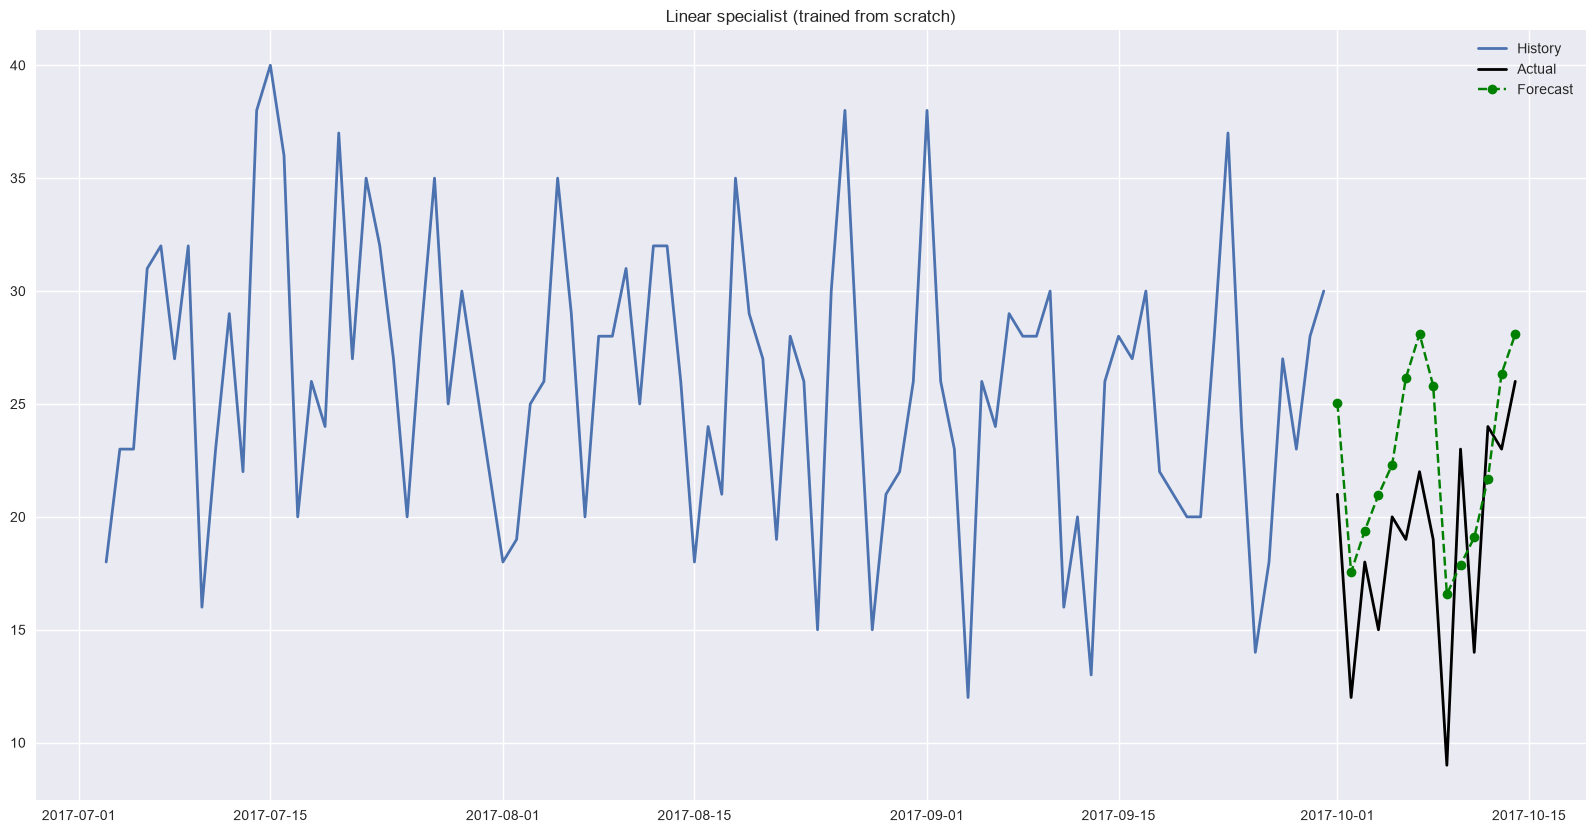

In [17]:
linear_forecasts = forecast_all_origins(linear_model)

hero_key = (origin0, CFG.HERO_ITEM)
print("Linear on the close-up series:",
      forecast_metrics(actual0, linear_forecasts[hero_key]))
plot_forecast(CFG.HERO_ITEM, origin0, linear_forecasts[hero_key],
              "Linear specialist (trained from scratch)")

This code generates forecasts using the trained linear model and evaluates its performance on the hero item at the first validation origin.

It calls the `forecast_all_origins` function with the `linear_model` to generate forecasts for all combinations of origins and items, storing the results in the `linear_forecasts` dictionary.

Then, it retrieves the forecast specifically for the hero item at the first validation origin (`origin0`) using the key `hero_key = (origin0, CFG.HERO_ITEM)`. It evaluates the accuracy of this forecast by calling the `forecast_metrics` function, comparing the predicted values to the actual values (`actual0`), and printing the resulting MAE and RMSE scores.

Finally, it generates a visualization of the linear model’s forecast for the hero item at the first origin using the `plot_forecast` function. The plot displays the historical data, actual values, and the linear model's predictions, allowing for visual assessment of its performance. The title indicates that this is a specialist model trained from scratch. This provides both quantitative (metrics) and qualitative (visualization) insights into the linear model’s forecasting capabilities on the hero item.

## A GRU forecaster

In [18]:
keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    gru_model = keras.Sequential([
        keras.layers.Input((CFG.LOOKBACK, 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(CFG.HORIZON)
    ])
gru_model.compile(optimizer='adam', loss='mse')

start = time.time()
early_stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history_gru = gru_model.fit(X_train[..., None], Y_train,
                            validation_data=(X_val[..., None], Y_val),
                            epochs=30, batch_size=256,
                            callbacks=[early_stop], verbose=0)
gru_train_time = time.time() - start

print(f"Parameters: {gru_model.count_params():,}")
print(f"Training: {gru_train_time:.1f}s"
      f" ({len(history_gru.history['loss'])} epochs)")

Parameters: 13,774
Training: 40.8s (19 epochs)


This code defines, compiles, and trains a Gated Recurrent Unit (GRU) model using Keras for time series forecasting.

It begins by setting the random seed for Keras to ensure reproducibility using `keras.utils.set_random_seed(CFG.SEED)`. Then, it uses a context manager (`with keras.device(DEVICE):`) to specify the computational device (CPU or GPU).

A sequential neural network called `gru_model` is created. It consists of an input layer that accepts sequences of shape `(CFG.LOOKBACK, 1)` – this indicates that each time step has a single feature; a GRU layer with 64 units to capture temporal dependencies in the data; and a dense (fully connected) layer with `CFG.HORIZON` output units for making predictions.

The model is compiled using the 'adam' optimizer and Mean Squared Error ('mse') as the loss function, suitable for regression tasks.

Next, the code measures the training time. An `EarlyStopping` callback is configured to stop training if validation loss doesn’t improve for 3 epochs, restoring the best weights encountered during training. The model is then trained using the `fit` method on the training data (`X_train[..., None]`, `Y_train`), with validation performed on the validation data (`X_val[..., None]`, `Y_val`). Note that `X_train[..., None]` and `X_val[..., None]` add an extra dimension to the input arrays, reshaping them to be compatible with the GRU layer’s expected input shape. Training runs for a maximum of 30 epochs with a batch size of 256, using the early stopping callback to prevent overfitting. The `verbose=0` argument suppresses output during training.

Finally, it calculates and prints the total number of parameters in the model using `gru_model.count_params()`, as well as the training time and the actual number of epochs trained (determined by the early stopping mechanism). This provides information about the model’s complexity and training efficiency.

GRU on the close-up series: {'mae': 5.79, 'rmse': 6.64}


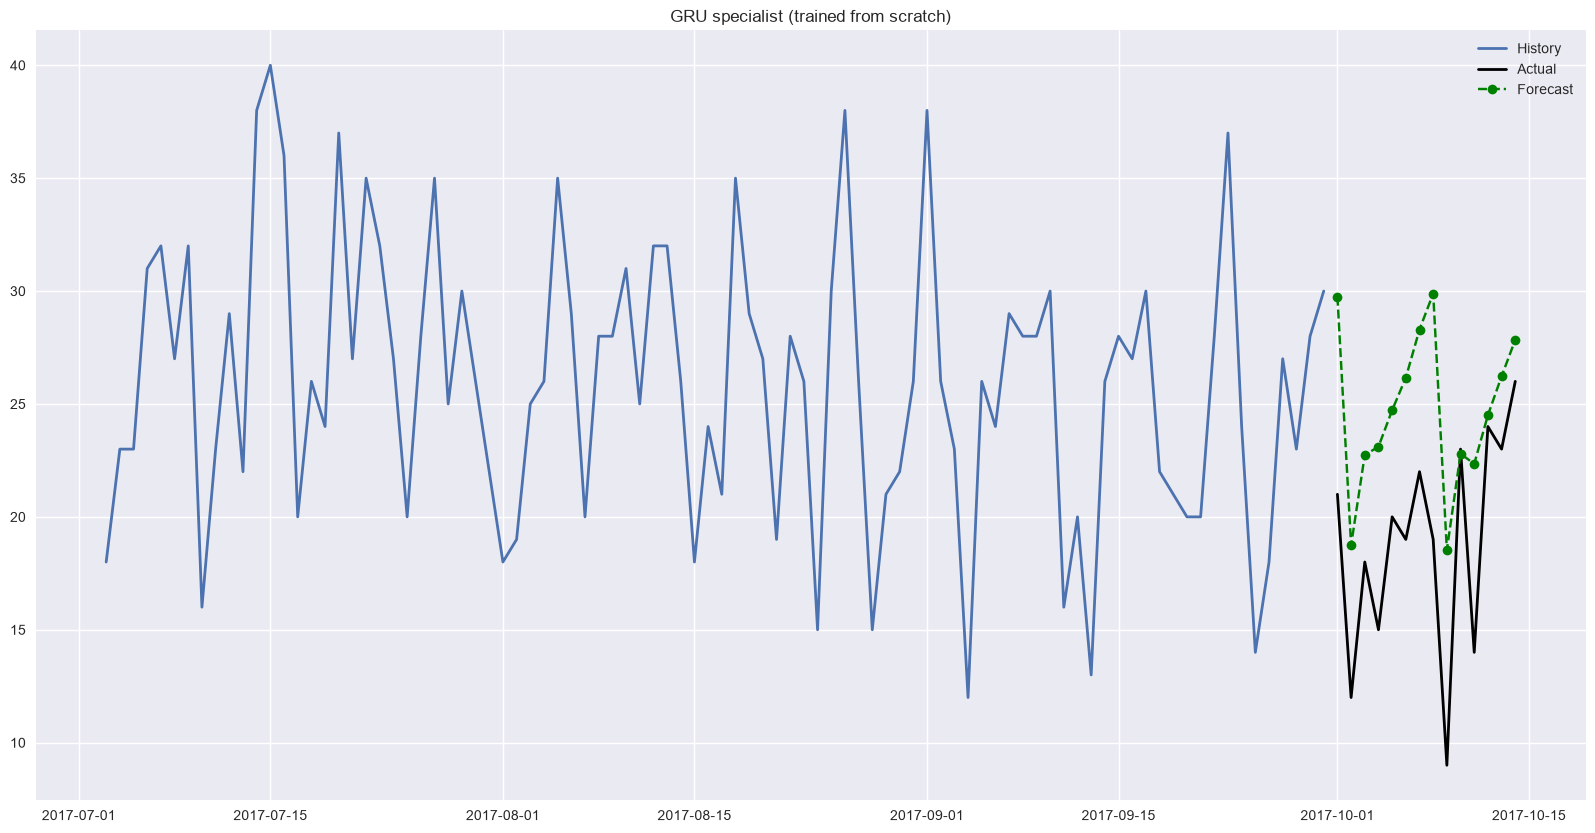

In [19]:
gru_forecasts = forecast_all_origins(gru_model, needs_3d=True)

print("GRU on the close-up series:",
      forecast_metrics(actual0, gru_forecasts[hero_key]))
plot_forecast(CFG.HERO_ITEM, origin0, gru_forecasts[hero_key],
              "GRU specialist (trained from scratch)")

This code generates forecasts using the trained GRU model and evaluates its performance on the hero item at the first validation origin.

It calls the `forecast_all_origins` function with the `gru_model`, setting `needs_3d=True`. This is because the GRU model expects a 3D input, which the function handles by adding an extra dimension to the context data during prediction. The forecasts for all combinations of origins and items are stored in the `gru_forecasts` dictionary.

Then, it retrieves the forecast specifically for the hero item at the first validation origin (`origin0`) using the key `hero_key = (origin0, CFG.HERO_ITEM)`. It evaluates the accuracy of this forecast by calling the `forecast_metrics` function, comparing the predicted values to the actual values (`actual0`), and printing the resulting MAE and RMSE scores.

Finally, it generates a visualization of the GRU model’s forecast for the hero item at the first origin using the `plot_forecast` function. The plot displays the historical data, actual values, and the GRU model's predictions, allowing for visual assessment of its performance. The title indicates that this is a specialist model trained from scratch using a GRU network. This provides both quantitative (metrics) and qualitative (visualization) insights into the GRU model’s forecasting capabilities on the hero item.

# How a foundation model reads a series

## Patching: sub-sequences as tokens

512 days -> 16 patches (tokens) of 32 days each
Attention cost vs. one-token-per-day: 0.0977%


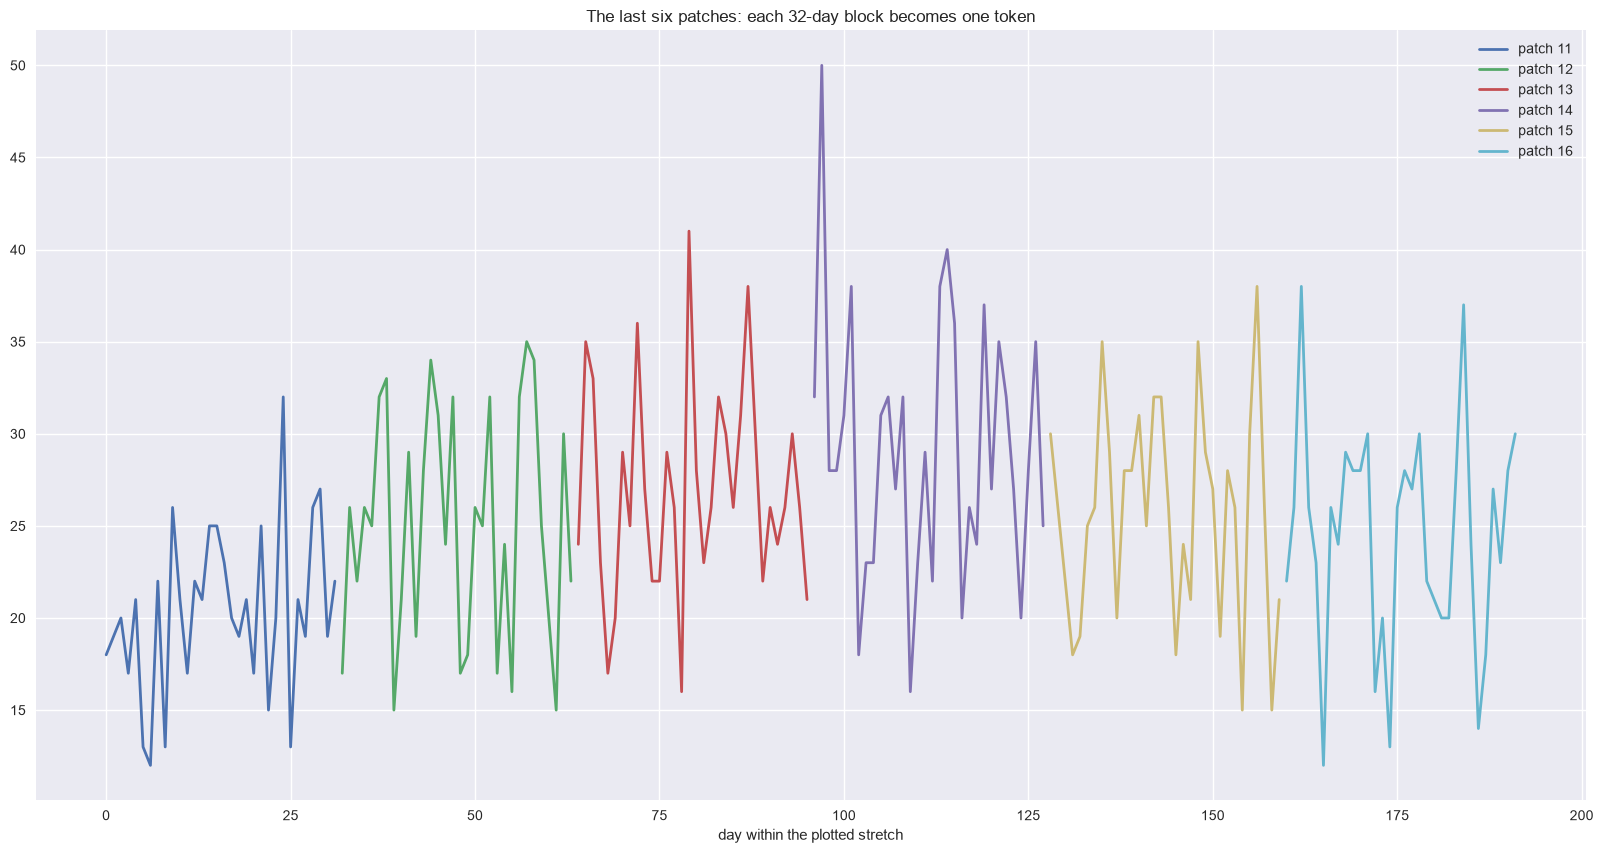

In [20]:
PATCH_LEN = 32
patches = context0.reshape(-1, PATCH_LEN)

print(f"{len(context0)} days -> {patches.shape[0]} patches (tokens) "
      f"of {PATCH_LEN} days each")
print(f"Attention cost vs. one-token-per-day: "
      f"{(patches.shape[0] ** 2) / (len(context0) ** 2):.4%}")

plt.figure()
for i in range(6):
    segment = patches[-6 + i]
    plt.plot(np.arange(i * PATCH_LEN, (i + 1) * PATCH_LEN), segment,
             linewidth=2, label=f"patch {patches.shape[0] - 6 + i + 1}")
plt.title("The last six patches: each 32-day block becomes one token")
plt.xlabel("day within the plotted stretch")
plt.legend()
plt.show()

This code prepares time series data for use with a transformer model by dividing it into fixed-length "patches" or tokens.

It defines `PATCH_LEN` as 32, representing the length of each patch in days. It then reshapes the `context0` array (the historical context) into a 2D array called `patches`, where each row represents a patch of length `PATCH_LEN`. This effectively converts the continuous time series data into a sequence of discrete tokens.

The code prints information about this transformation: the number of days in the original context and the resulting number of patches (tokens), as well as the ratio of the computational cost of attention between patches compared to attention between individual days. The attention cost is calculated as the square of the number of patches divided by the square of the number of days, illustrating how patchification reduces the sequence length and thus the computational complexity of attention mechanisms.

Finally, it generates a visualization showing the last six patches. For each patch, it plots the values against their corresponding day within the original context using Matplotlib. The plot is titled to explain that each 32-day block becomes one token, and the x-axis is labeled "day within the plotted stretch." A legend identifies each patch in the plot. This visualization helps understand how the continuous time series data is segmented into discrete tokens for use with a transformer model.

## Quantization: sales as sentences

In [21]:
N_BINS = 4096
scale = np.mean(np.abs(context0))
scaled = context0 / scale

bin_edges = np.linspace(scaled.min(), scaled.max(), N_BINS + 1)
tokens = np.clip(np.digitize(scaled, bin_edges) - 1, 0, N_BINS - 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
reconstructed = bin_centers[tokens] * scale

round_trip_rmse = float(np.sqrt(np.mean((context0 - reconstructed) ** 2)))
print("Vocabulary size:", N_BINS)
print("Tokens actually used by this series:", len(np.unique(tokens)))
print("First ten tokens:", tokens[:10])
print("Round-trip error (RMSE, sales units):", round(round_trip_rmse, 4))

Vocabulary size: 4096
Tokens actually used by this series: 37
First ten tokens: [1638 1911 1183 2184 1456 1274 1911 2275 3094  728]
Round-trip error (RMSE, sales units): 0.002


This code implements a quantization technique to create a discrete vocabulary of "tokens" from the continuous time series data. This is often done when preparing data for transformer models that operate on discrete inputs.

It first defines `N_BINS` as 4096, representing the desired size of the vocabulary (the number of unique tokens). It then calculates the mean absolute value of the context data (`context0`) and uses it to scale the data, normalizing its range.

Next, it creates a set of evenly spaced bin edges using `np.linspace`, defining the boundaries for each token. The `np.digitize` function assigns each scaled value in `context0` to a specific bin (token) based on these edges.  The `- 1` adjustment ensures that tokens are numbered from 0 to `N_BINS - 1`. `np.clip` is used to ensure all token values fall within the valid range of indices.

It then calculates the centers of each bin (`bin_centers`). These centers represent the "meaning" or value associated with each token. The original data can be approximately reconstructed by multiplying the corresponding bin center for each token by the scaling factor. This is done in `reconstructed`.

Finally, it calculates the root mean squared error (RMSE) between the original context data and the reconstructed data (`round_trip_rmse`), quantifying the information loss due to quantization. It prints several statistics: the vocabulary size (`N_BINS`), the number of unique tokens actually used by this specific time series, the first ten tokens in the sequence, and the round-trip RMSE in sales units (rounded to four decimal places). This provides insights into the effectiveness of the quantization process – how well it preserves information while reducing the dimensionality of the data.

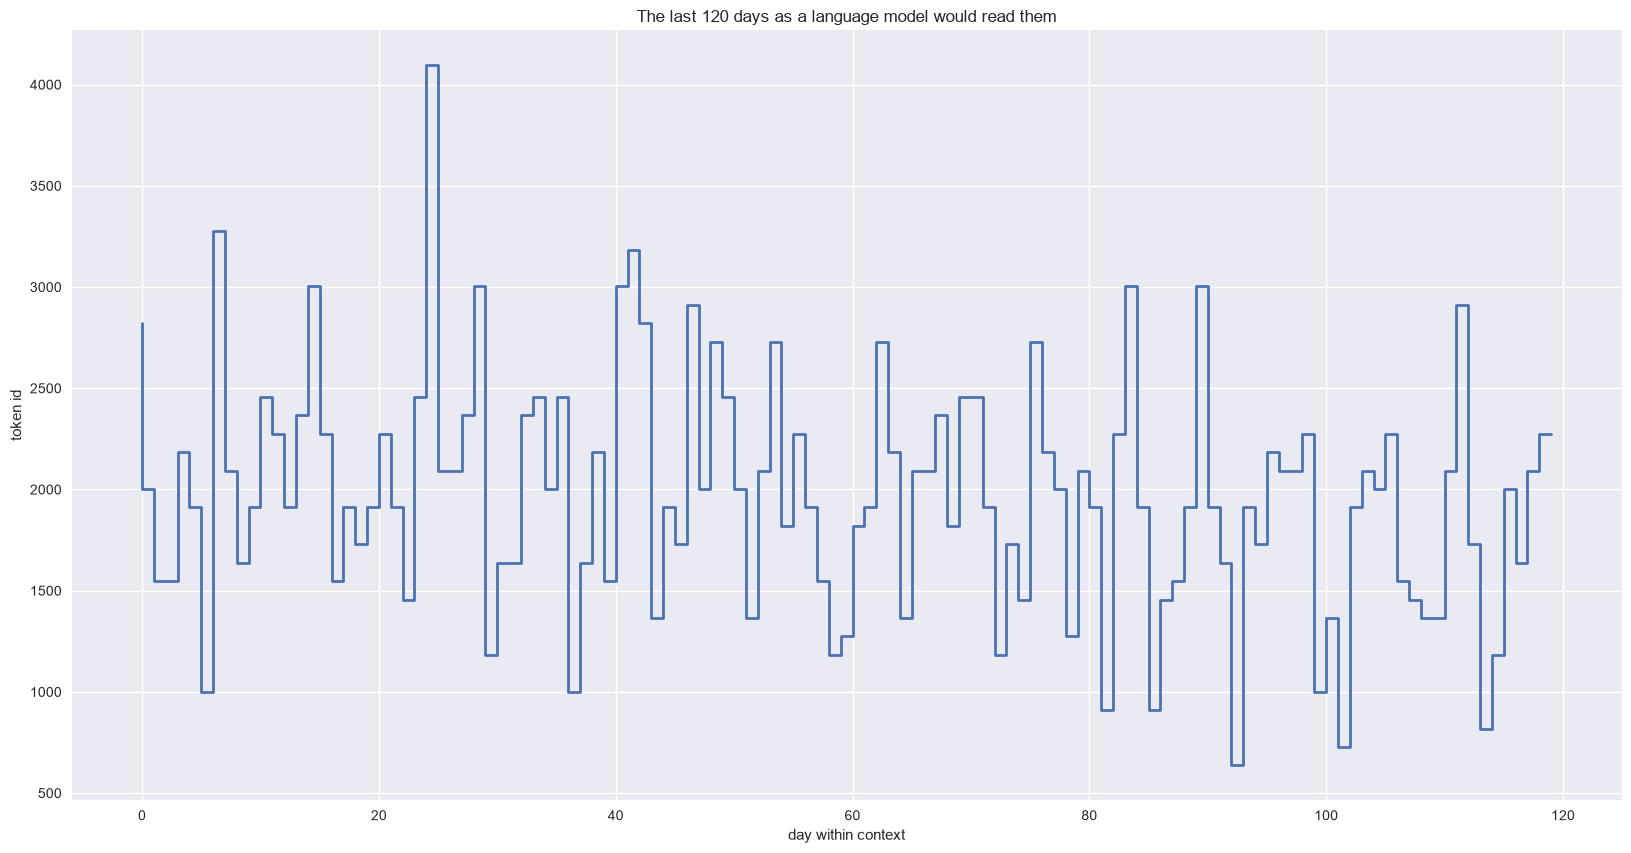

In [22]:
plt.figure()
plt.step(np.arange(120), tokens[-120:], linewidth=2)
plt.title("The last 120 days as a language model would read them")
plt.xlabel("day within context")
plt.ylabel("token id")
plt.show()

This code generates a visualization of the tokenized time series data, showing how the sequence of values is represented as a discrete sequence of tokens for a language model or transformer.

It creates a plot using Matplotlib and displays the last 120 tokens from the `tokens` array as a step function. The x-axis represents the day within the context (the last 120 days), and the y-axis represents the token ID assigned to each day’s value.

The plot is titled "The last 120 days as a language model would read them," emphasizing that this visualization shows how the continuous time series data is perceived by a discrete sequence processing model like a transformer. The x and y axes are labeled accordingly. This allows for visual inspection of the tokenized representation, revealing patterns and characteristics of the transformed data.

# The zero-shot ladder


## TimesFM 2.5

In [23]:
start = time.time()
timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch")
timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=CFG.CONTEXT,
        max_horizon=64,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        fix_quantile_crossing=True,
    )
)
print(f"Loaded and compiled in {time.time() - start:.1f}s")

Loaded and compiled in 1.2s


This code loads and compiles a pre-trained Time Series Forecasting Model (TimesFM) from Hugging Face Transformers.

It begins by measuring the loading and compilation time using `time.time()`. It then uses the `from_pretrained` method of the `timesfm.TimesFM_2p5_200M_torch` class to load a pre-trained TimesFM model with 2.5 billion parameters ("google/timesfm-2.5-200m-pytorch"). This downloads the model weights and configuration from Hugging Face’s model hub.

Next, it compiles the loaded model using `timesfm_model.compile`. The compilation process configures the model for forecasting tasks by specifying several key parameters:
*   `max_context`: Sets the maximum length of the input context window to `CFG.CONTEXT`.
*   `max_horizon`: Sets the maximum forecast horizon to 64.
*   `normalize_inputs`: Enables normalization of the input features.
*   `use_continuous_quantile_head`: Activates a continuous quantile head for probabilistic forecasting.
*   `fix_quantile_crossing`: Enforces constraints on quantile crossing during prediction.

Finally, it prints the time taken to load and compile the model. This provides an indication of the computational cost associated with initializing the TimesFM model. The compiled model is now ready to be used for generating forecasts.

In [24]:
timesfm_point, timesfm_quantiles = {}, {}

start = time.time()
for origin in origins:
    inputs = [context_for(item, origin, CFG.CONTEXT).astype('float32')
              for item in CFG.ARENA_ITEMS]
    point, quantiles = timesfm_model.forecast(horizon=CFG.HORIZON, inputs=inputs)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        timesfm_point[(origin, item)] = point[j]
        timesfm_quantiles[(origin, item)] = quantiles[j]  # (14, 10): mean, q10..q90
timesfm_time = time.time() - start

print(f"All {len(origins) * len(CFG.ARENA_ITEMS)} two-week forecasts "
      f"in {timesfm_time:.1f}s - zero training")

All 120 two-week forecasts in 6.3s - zero training


This code generates point forecasts and probabilistic quantile forecasts for all items at each validation origin using the pre-trained TimesFM model.

It initializes two dictionaries, `timesfm_point` to store the point forecasts (mean predictions) and `timesfm_quantiles` to store the predicted quantiles.

The code then iterates through each origin in the `origins` sequence. For each origin, it retrieves the historical context for all items in `CFG.ARENA_ITEMS` using the `context_for` function, converting the data to a float32 NumPy array. These contexts are collected into a list called `inputs`.

It then calls the `timesfm_model.forecast` method with the specified horizon (`CFG.HORIZON`) and input contexts (`inputs`). The model returns two outputs: `point`, representing the point forecasts (mean predictions) for each item, and `quantiles`, containing the predicted quantiles (e.g., 10th percentile, 90th percentile).

The code then iterates through the items and stores the corresponding point forecast and quantile predictions in the `timesfm_point` and `timesfm_quantiles` dictionaries, respectively, using a tuple of (origin, item) as the key.

Finally, it calculates and prints the total time taken to generate all forecasts across all origins and items. The message emphasizes that these forecasts were generated without any training – leveraging the pre-trained model’s knowledge directly. This demonstrates the potential for zero-shot forecasting with large foundation models like TimesFM.

TimesFM 2.5: {'mae': 4.95, 'rmse': 5.55}
80% interval coverage: 0.64


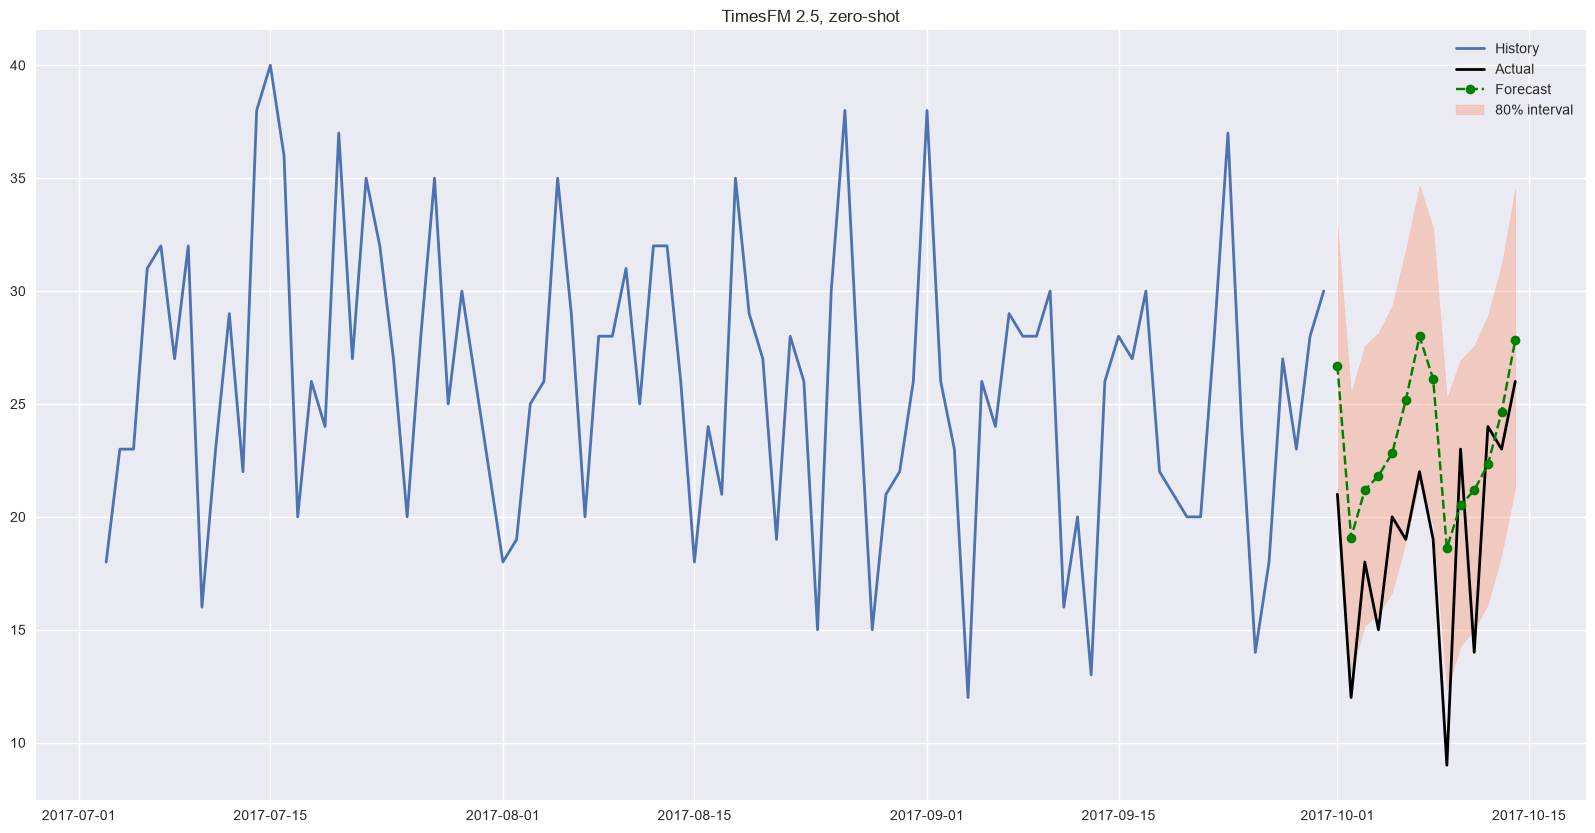

In [25]:
q = timesfm_quantiles[hero_key]
print("TimesFM 2.5:", forecast_metrics(actual0, timesfm_point[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 1], q[:, 9]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, timesfm_point[hero_key],
              "TimesFM 2.5, zero-shot", lower=q[:, 1], upper=q[:, 9])

This code evaluates the performance of the TimesFM model on the hero item at the first validation origin and visualizes its probabilistic forecast.

It retrieves the predicted quantiles (`q`) for the hero item at `origin0` from the `timesfm_quantiles` dictionary. It then calculates and prints the point forecast accuracy metrics (MAE and RMSE) using the `forecast_metrics` function, comparing the TimesFM’s point prediction to the actual values (`actual0`).

Next, it evaluates the coverage of the 80% prediction interval generated by the model. It calls the `interval_coverage` function with the actual values (`actual0`), the lower bound of the 80% interval (the 10th percentile quantile – `q[:, 1]`), and the upper bound of the 80% interval (the 90th percentile quantile – `q[:, 9]`). The result, representing the fraction of actual values falling within the predicted interval, is rounded to two decimal places and printed.

Finally, it generates a visualization of the TimesFM’s forecast using the `plot_forecast` function. It displays the historical data, actual values, point forecast, and the 80% prediction interval (defined by the 10th and 90th percentile quantiles). The plot is titled "TimesFM 2.5, zero-shot" to indicate that the forecasts were generated using a pre-trained model without any fine-tuning. This provides both quantitative metrics and a visual assessment of the TimesFM’s forecasting performance on the hero item.

## TiRex-2

In [26]:
start = time.time()
tirex2_model = load_model("NX-AI/TiRex-2", device=DEVICE)
print(f"Loaded in {time.time() - start:.1f}s")


def forecast_tirex2(contexts, horizon):
    """Forecast independent series; return (batch, horizon, 9) deciles and q50."""
    timeseries = [
        TimeseriesType(
            target=torch.tensor(context, dtype=torch.float32).reshape(1, -1),
            past_covariates=None,
            future_covariates=None,
        )
        for context in contexts
    ]
    forecasts = tirex2_model.forecast(
        timeseries, prediction_length=horizon, output_type="numpy")
    # Each result is (1 target, 9 quantiles, horizon); scorers expect time first.
    quantiles = np.stack([forecast[0].T for forecast in forecasts])
    point = quantiles[:, :, 4]  # q50 (median), not a predictive mean
    return quantiles, point


tirex2_point, tirex2_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = [context_for(item, origin, CFG.CONTEXT)
                for item in CFG.ARENA_ITEMS]
    quantiles, point = forecast_tirex2(contexts, CFG.HORIZON)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        tirex2_quantiles[(origin, item)] = quantiles[j]  # (14, 9): q10..q90
        tirex2_point[(origin, item)] = point[j]
tirex2_time = time.time() - start

print(f"All {len(tirex2_point)} forecasts in {tirex2_time:.1f}s")

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 10106.76it/s]


Loaded in 0.5s
All 120 forecasts in 2.6s


This code loads the TiRex-2 model and generates forecasts for all items at each validation origin using this model.

It begins by loading the pre-trained TiRex-2 model from Hugging Face Transformers using the `load_model` function, specifying the device (`DEVICE`) to use for computation. The loading time is measured and printed.

Next, it defines a helper function called `forecast_tirex2`. This function takes a list of contexts (historical data) and a forecast horizon as input. It converts each context into a `TimeseriesType` object, which is the expected input format for TiRex-2. The model then generates forecasts using the `tirex2_model.forecast` method, requesting output in NumPy format. The function extracts the predicted quantiles (9 deciles) and point forecast (median – q50) from the model’s output and returns them.

The code then initializes two dictionaries, `tirex2_point` to store the point forecasts and `tirex2_quantiles` to store the quantile predictions. It iterates through each origin in the `origins` sequence, retrieves the historical context for all items using the `context_for` function, and calls the `forecast_tirex2` function to generate forecasts. The resulting quantiles and point forecasts are stored in the respective dictionaries, keyed by a tuple of (origin, item).

Finally, it calculates and prints the total time taken to generate all forecasts across all origins and items using TiRex-2. This provides an indication of the model’s inference speed.

TiRex-2: {'mae': 5.38, 'rmse': 6.05}
80% interval coverage: 0.43


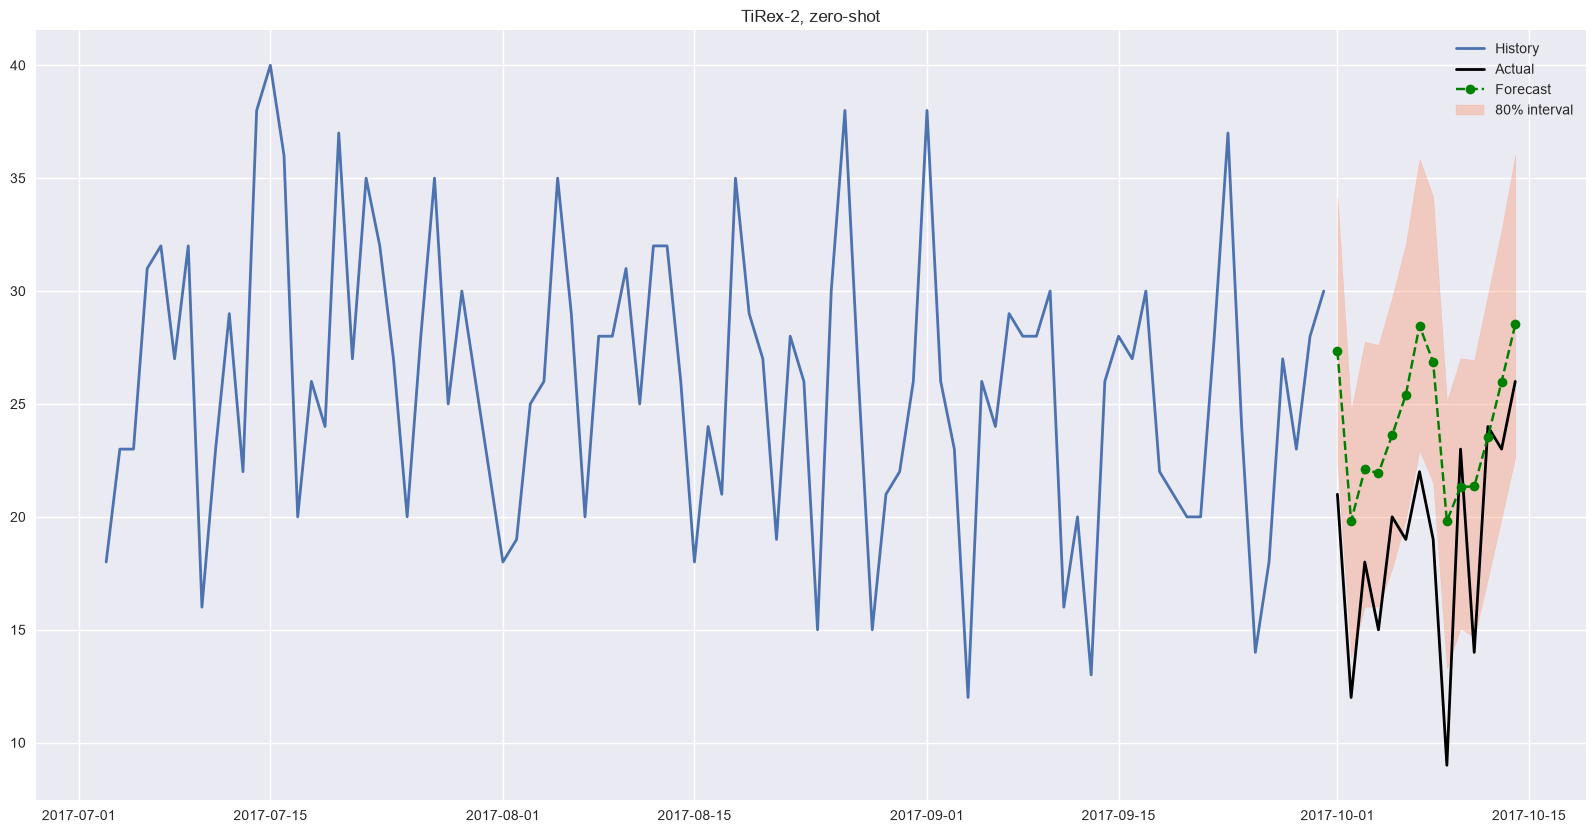

In [27]:
q = tirex2_quantiles[hero_key]
print("TiRex-2:", forecast_metrics(actual0, tirex2_point[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 0], q[:, 8]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, tirex2_point[hero_key],
              "TiRex-2, zero-shot", lower=q[:, 0], upper=q[:, 8])

This code evaluates the performance of the TiRex-2 model on the hero item at the first validation origin and visualizes its probabilistic forecast.

It retrieves the predicted quantiles (`q`) for the hero item at `origin0` from the `tirex2_quantiles` dictionary. It then calculates and prints the point forecast accuracy metrics (MAE and RMSE) using the `forecast_metrics` function, comparing the TiRex-2’s point prediction to the actual values (`actual0`).

Next, it evaluates the coverage of the 80% prediction interval generated by the model. It calls the `interval_coverage` function with the actual values (`actual0`), the lower bound of the 80% interval (the 10th percentile quantile – `q[:, 0]`), and the upper bound of the 80% interval (the 90th percentile quantile – `q[:, 8]`). The result, representing the fraction of actual values falling within the predicted interval, is rounded to two decimal places and printed.

Finally, it generates a visualization of the TiRex-2’s forecast using the `plot_forecast` function. It displays the historical data, actual values, point forecast, and the 80% prediction interval (defined by the 10th and 90th percentile quantiles). The plot is titled "TiRex-2, zero-shot" to indicate that the forecasts were generated using a pre-trained model without any fine-tuning. This provides both quantitative metrics and a visual assessment of the TiRex-2’s forecasting performance on the hero item.

## Chronos-2

In [28]:
start = time.time()
chronos_model = BaseChronosPipeline.from_pretrained("amazon/chronos-2",
                                                    device_map=DEVICE)
print(f"Loaded in {time.time() - start:.1f}s")

chronos_mean, chronos_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = torch.tensor(
        np.stack([context_for(item, origin, CFG.CONTEXT)
                  for item in CFG.ARENA_ITEMS]),
        dtype=torch.float32).unsqueeze(1)   # (10 series, 1 variate, 512 days)
    q_list, mean_list = chronos_model.predict_quantiles(
        contexts, prediction_length=CFG.HORIZON,
        quantile_levels=CFG.QUANTILES)
    for j, item in enumerate(CFG.ARENA_ITEMS):
        chronos_quantiles[(origin, item)] = q_list[j][0].numpy()  # (14, 3)
        chronos_mean[(origin, item)] = mean_list[j][0].numpy()
chronos_time = time.time() - start

print(f"All 120 forecasts in {chronos_time:.1f}s")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 71943.46it/s]


Loaded in 0.8s
All 120 forecasts in 0.4s


This code loads the Chronos model and generates forecasts for all items at each validation origin using this model.

It begins by loading the pre-trained Chronos model from Hugging Face Transformers using `BaseChronosPipeline.from_pretrained`, specifying the device (`DEVICE`) to use for computation. The loading time is measured and printed.

Next, it initializes two dictionaries: `chronos_mean` to store the point forecasts (means) and `chronos_quantiles` to store the predicted quantiles. It then iterates through each origin in the `origins` sequence. For each origin, it retrieves the historical context for all items using the `context_for` function and stacks these contexts into a 3D NumPy array. This array is converted to a PyTorch tensor with a data type of float32 and unsqueezed to add a batch dimension, resulting in a shape of (10 series, 1 variate, 512 days).

It then calls the `chronos_model.predict_quantiles` method with the contexts, forecast horizon (`CFG.HORIZON`), and desired quantile levels (`CFG.QUANTILES`). The model returns two outputs: `q_list`, containing the predicted quantiles for each item, and `mean_list`, containing the point forecasts (means) for each item.

The code then iterates through the items and stores the corresponding quantile predictions and mean forecasts in the `chronos_quantiles` and `chronos_mean` dictionaries, respectively, using a tuple of (origin, item) as the key. The quantiles are extracted from the nested structure of `q_list` and converted to NumPy arrays.

Finally, it calculates and prints the total time taken to generate all forecasts across all origins and items using Chronos. This provides an indication of the model’s inference speed.

Chronos-2: {'mae': 4.9, 'rmse': 5.62}
80% interval coverage: 0.57


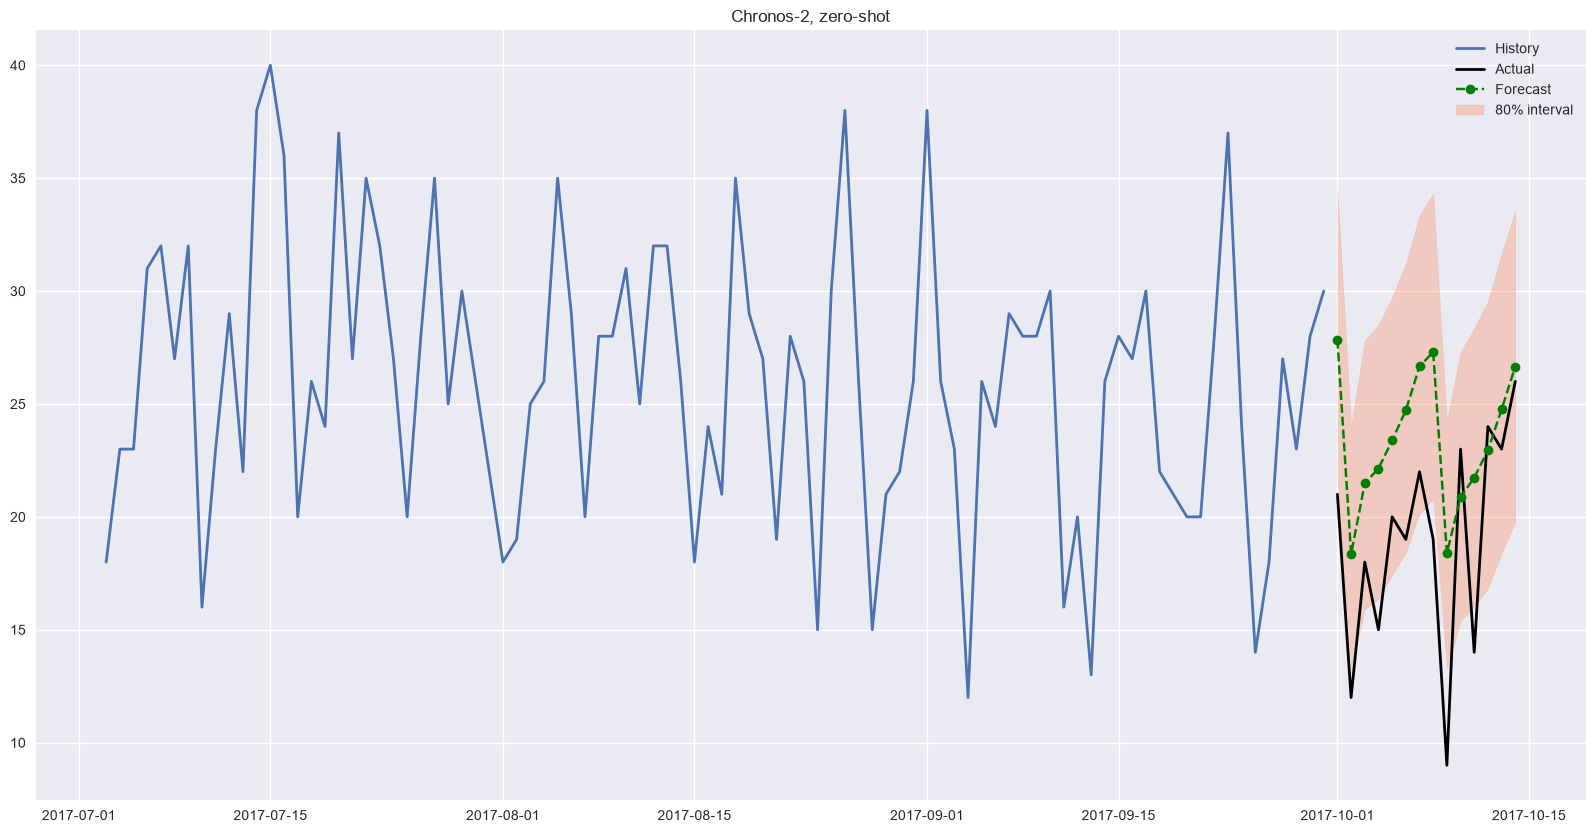

In [29]:
q = chronos_quantiles[hero_key]
print("Chronos-2:", forecast_metrics(actual0, chronos_mean[hero_key]))
print("80% interval coverage:",
      round(interval_coverage(actual0, q[:, 0], q[:, 2]), 2))

plot_forecast(CFG.HERO_ITEM, origin0, chronos_mean[hero_key],
              "Chronos-2, zero-shot", lower=q[:, 0], upper=q[:, 2])

This code evaluates the performance of the Chronos model on the hero item at the first validation origin and visualizes its probabilistic forecast.

It retrieves the predicted quantiles (`q`) for the hero item at `origin0` from the `chronos_quantiles` dictionary. It then calculates and prints the point forecast accuracy metrics (MAE and RMSE) using the `forecast_metrics` function, comparing the Chronos’s point prediction to the actual values (`actual0`).

Next, it evaluates the coverage of the 80% prediction interval generated by the model. It calls the `interval_coverage` function with the actual values (`actual0`), the lower bound of the 80% interval (the 10th percentile quantile – `q[:, 0]`), and the upper bound of the 80% interval (the 90th percentile quantile – `q[:, 2]`). The result, representing the fraction of actual values falling within the predicted interval, is rounded to two decimal places and printed.

Finally, it generates a visualization of the Chronos’s forecast using the `plot_forecast` function. It displays the historical data, actual values, point forecast, and the 80% prediction interval (defined by the 10th and 90th percentile quantiles). The plot is titled "Chronos-2, zero-shot" to indicate that the forecasts were generated using a pre-trained model without any fine-tuning. This provides both quantitative metrics and a visual assessment of the Chronos’s forecasting performance on the hero item.

In [30]:
all_items = list(panel.columns)

group_mean, group_quantiles = {}, {}
start = time.time()
for origin in origins:
    contexts = torch.tensor(
        np.stack([context_for(item, origin, CFG.CONTEXT)
                  for item in all_items]),
        dtype=torch.float32).unsqueeze(0)   # (1 task, 50 variates, 512 days)
    q_list, mean_list = chronos_model.predict_quantiles(
        contexts, prediction_length=CFG.HORIZON,
        quantile_levels=CFG.QUANTILES)
    for j, item in enumerate(all_items):
        if item in CFG.ARENA_ITEMS:
            group_quantiles[(origin, item)] = q_list[0][j].numpy()
            group_mean[(origin, item)] = mean_list[0][j].numpy()
group_time = time.time() - start

print(f"Group mode, 50 items jointly: {group_time:.1f}s")
print("Close-up item, forecast alone:     ",
      forecast_metrics(actual0, chronos_mean[hero_key]))
print("Close-up item, forecast in a group:",
      forecast_metrics(actual0, group_mean[hero_key]))

Group mode, 50 items jointly: 0.8s
Close-up item, forecast alone:      {'mae': 4.9, 'rmse': 5.62}
Close-up item, forecast in a group: {'mae': 5.08, 'rmse': 5.71}


This code explores the "group mode" forecasting capability of the Chronos model, where it forecasts all items simultaneously. It then compares the performance of forecasting the hero item alone versus forecasting it within this larger group context.

It first defines `all_items` as a list of all columns in the `panel`, representing all available time series.

Next, it initializes two dictionaries: `group_mean` to store point forecasts and `group_quantiles` to store quantile predictions when forecasting all items together. It iterates through each origin in the `origins` sequence. For each origin, it retrieves the historical context for *all* items using the `context_for` function and stacks these contexts into a 3D NumPy array. This array is converted to a PyTorch tensor with a data type of float32 and unsqueezed to add a batch dimension, resulting in a shape of (1 task, 50 variates, 512 days). The "task" dimension represents the entire group of items being forecasted simultaneously.

It then calls the `chronos_model.predict_quantiles` method with the combined contexts, forecast horizon (`CFG.HORIZON`), and desired quantile levels (`CFG.QUANTILES`). The model returns two outputs: `q_list`, containing the predicted quantiles for each item, and `mean_list`, containing the point forecasts (means) for each item.

The code then iterates through all items. If an item is present in `CFG.ARENA_ITEMS` (the set of items used for evaluation), it stores the corresponding quantile predictions and mean forecasts in the `group_quantiles` and `group_mean` dictionaries, respectively, using a tuple of (origin, item) as the key.

Finally, it calculates and prints the total time taken to generate all group forecasts. It then compares the performance of forecasting the hero item alone (using the previously calculated `chronos_mean[hero_key]`) with the performance of forecasting the hero item within the larger group context (using `group_mean[hero_key]`), printing the MAE and RMSE for both scenarios using the `forecast_metrics` function. This allows assessment of whether leveraging relationships between items improves forecast accuracy for a specific item.

# Head-to-head

In [31]:
snaive_forecasts = {}
for origin in origins:
    for item in CFG.ARENA_ITEMS:
        last_week = context_for(item, origin, 7)
        snaive_forecasts[(origin, item)] = np.tile(last_week, 3)[:CFG.HORIZON]

# the ground truth for all 120 tasks, concatenated once and shared by both scorers
ARENA_ACTUALS = np.concatenate([actuals_for(item, o)
                                for o in origins for item in CFG.ARENA_ITEMS])

def arena_rmse(forecasts):
    """Pooled RMSE over all (origin, item) tasks."""
    preds = np.concatenate([forecasts[(o, item)]
                            for o in origins for item in CFG.ARENA_ITEMS])
    return forecast_metrics(ARENA_ACTUALS, preds)['rmse']

def arena_prob(point_fc, quantile_fc, lo_col, med_col, hi_col):
    """RMSE + averaged pinball + 80% coverage for a quantile model."""
    stack = lambda col: np.concatenate([quantile_fc[(o, item)][:, col]
                                        for o in origins
                                        for item in CFG.ARENA_ITEMS])
    lo, med, hi = stack(lo_col), stack(med_col), stack(hi_col)
    points = np.concatenate([point_fc[(o, item)]
                            for o in origins for item in CFG.ARENA_ITEMS])
    pinball = np.mean([pinball_loss(ARENA_ACTUALS, lo, 0.1),
                       pinball_loss(ARENA_ACTUALS, med, 0.5),
                       pinball_loss(ARENA_ACTUALS, hi, 0.9)])
    return {'rmse': forecast_metrics(ARENA_ACTUALS, points)['rmse'],
            'pinball': round(float(pinball), 2),
            'coverage_80': round(interval_coverage(ARENA_ACTUALS, lo, hi), 2)}

This code defines functions to evaluate the performance of forecasting models across all validation origins and items in a pooled manner. It also prepares forecasts from a simple seasonal naive model for comparison.

It first generates seasonal naive forecasts for each item at each origin and stores them in the `snaive_forecasts` dictionary. For each (origin, item) pair, it retrieves the last week of historical data using `context_for`, repeats this week three times, and truncates the result to match the forecast horizon (`CFG.HORIZON`).

Next, it creates a concatenated array called `ARENA_ACTUALS` containing the actual values for all items at all validation origins. This serves as the ground truth for evaluating the models across all tasks.

It then defines two evaluation functions:
*   **`arena_rmse(forecasts)`:** This function calculates the pooled Root Mean Squared Error (RMSE) over all (origin, item) pairs. It concatenates the forecasts from the input dictionary `forecasts` into a single array and compares it to `ARENA_ACTUALS` using the `forecast_metrics` function.
*   **`arena_prob(point_fc, quantile_fc, lo_col, med_col, hi_col)`:** This function calculates a combined score that includes RMSE, average pinball loss (for probabilistic forecasting), and 80% interval coverage. It takes the point forecasts (`point_fc`) and quantile forecasts (`quantile_fc`) as input, along with column indices for the lower bound (10th percentile – `lo_col`), median (50th percentile – `med_col`), and upper bound (90th percentile – `hi_col`). It concatenates the relevant quantiles from all tasks, calculates pinball loss for each quantile level using the `pinball_loss` function, computes interval coverage using the `interval_coverage` function, and returns a dictionary containing the RMSE, average pinball loss, and 80% coverage.

These functions provide a comprehensive way to evaluate forecasting models across multiple time series and validation origins, considering both point forecast accuracy and probabilistic calibration.

In [32]:
results = []
results.append({'model': 'Seasonal naive (7)', 'zero_shot': '-',
                'rmse': arena_rmse(snaive_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan, 'compute_s': 0.0})
results.append({'model': 'Linear (trained)', 'zero_shot': 'no',
                'rmse': arena_rmse(linear_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan,
                'compute_s': round(linear_train_time, 1)})
results.append({'model': 'GRU (trained)', 'zero_shot': 'no',
                'rmse': arena_rmse(gru_forecasts),
                'pinball': np.nan, 'coverage_80': np.nan,
                'compute_s': round(gru_train_time, 1)})
results.append({'model': 'TimesFM 2.5', 'zero_shot': 'yes',
                **arena_prob(timesfm_point, timesfm_quantiles, 1, 5, 9),
                'compute_s': round(timesfm_time, 1)})
results.append({'model': 'TiRex-2', 'zero_shot': 'yes',
                **arena_prob(tirex2_point, tirex2_quantiles, 0, 4, 8),
                'compute_s': round(tirex2_time, 1)})
results.append({'model': 'Chronos-2', 'zero_shot': 'yes',
                **arena_prob(chronos_mean, chronos_quantiles, 0, 1, 2),
                'compute_s': round(chronos_time, 1)})
results.append({'model': 'Chronos-2 (group)', 'zero_shot': 'yes',
                **arena_prob(group_mean, group_quantiles, 0, 1, 2),
                'compute_s': round(group_time, 1)})

results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['zero_shot', 'rmse', 'pinball', 'coverage_80', 'compute_s']]
results_df

,zero_shot,rmse,pinball,coverage_80,compute_s
model,,,,,
Seasonal naive (7),-,11.55,NaN,NaN,0.0
Linear (trained),no,9.46,NaN,NaN,4.3
GRU (trained),no,9.37,NaN,NaN,40.8
TimesFM 2.5,yes,8.30,1.98,0.79,6.3
TiRex-2,yes,9.30,2.23,0.75,2.6
Chronos-2,yes,7.74,1.86,0.80,0.4
Chronos-2 (group),yes,8.01,1.91,0.79,0.8


This code consolidates the evaluation results of all forecasting models into a Pandas DataFrame for easy comparison and analysis.

It initializes an empty list called `results`. Then, it appends dictionaries to this list, each representing the performance of a different model. Each dictionary contains the following keys:
*   `model`: The name of the model.
*   `zero_shot`: Indicates whether the model was used in a zero-shot manner (without training).
*   `rmse`: The pooled RMSE score calculated using `arena_rmse`.
*   `pinball`: The average pinball loss, applicable only to probabilistic models.
*   `coverage_80`: The 80% interval coverage, also applicable only to probabilistic models.
*   `compute_s`: The computation time (in seconds) for generating forecasts with the model.

The results are added for: seasonal naive forecasting, linear regression, GRU, TimesFM 2.5, TiRex-2, Chronos-2 in a single-item mode, and Chronos-2 in group mode.  For models that provide quantile predictions (TimesFM, TiRex-2, and both Chronos modes), the `arena_prob` function is called to calculate pinball loss and coverage, and its results are unpacked into the dictionary using the `**` operator. For the seasonal naive model, `pinball` and `coverage_80` are set to NaN because it doesn't produce quantile forecasts.

Finally, it creates a Pandas DataFrame from the `results` list, setting the 'model' column as the index. It then selects only the relevant columns (`zero_shot`, `rmse`, `pinball`, `coverage_80`, and `compute_s`) to create a concise summary table of model performance. The resulting DataFrame is stored in the variable `results_df`. This provides a structured overview of the forecasting results, allowing for easy comparison of different models based on various evaluation metrics.

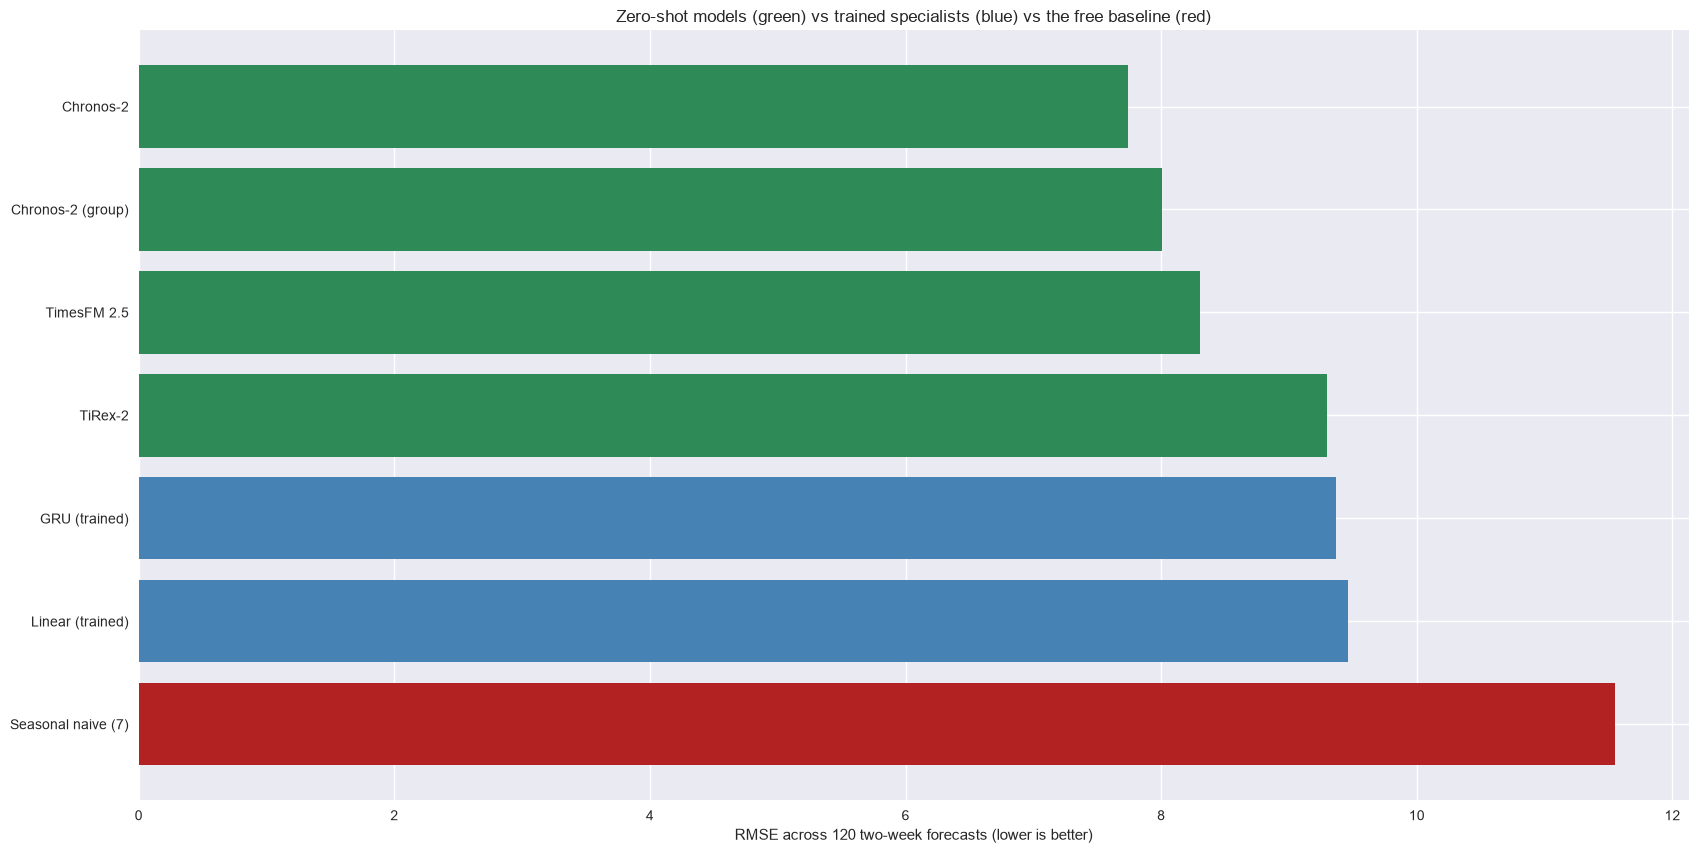

In [33]:
plot_df = results_df.sort_values('rmse', ascending=False)
palette = {'yes': 'seagreen', 'no': 'steelblue', '-': 'firebrick'}
colors = [palette[z] for z in plot_df['zero_shot']]

plt.figure()
plt.barh(plot_df.index, plot_df['rmse'], color=colors)
plt.xlabel("RMSE across 120 two-week forecasts (lower is better)")
plt.title("Zero-shot models (green) vs trained specialists (blue) vs the free baseline (red)")
plt.show()

This code generates a horizontal bar chart visualizing the RMSE performance of the different forecasting models.

It first sorts the `results_df` DataFrame by the 'rmse' column in descending order, so that the model with the highest RMSE is at the top of the chart. It then defines a color palette where green represents zero-shot models, blue represents trained specialists, and red represents the free baseline (seasonal naive).

It creates a list called `colors` by applying this palette to the 'zero_shot' column of the sorted DataFrame, assigning a color to each model based on whether it was used in a zero-shot manner or not.

Next, it generates a horizontal bar chart using Matplotlib’s `plt.barh` function. The x-axis represents the RMSE values, and the y-axis displays the names of the models (taken from the index of the sorted DataFrame). The bars are colored according to the `colors` list.

Finally, it sets the x-axis label to "RMSE across 120 two-week forecasts (lower is better)" and adds a title explaining that green represents zero-shot models, blue represents trained specialists, and red represents the free baseline. This visualization provides a clear comparison of the forecasting performance of different models, highlighting the benefits of zero-shot learning versus training and providing context for the seasonal naive baseline.

# Application: the cold-start problem

In [34]:
COLD_DAYS = 60
COLD_LOOKBACK = 28
cold_context = context_for(CFG.HERO_ITEM, origin0, COLD_DAYS)

cold_scores = {}
cold_scores['Seasonal naive (7)'] = forecast_metrics(
    actual0, np.tile(cold_context[-7:], 3)[:CFG.HORIZON])['rmse']

# scratch models on 60 days: standardise, window, train
cold_mean, cold_std = float(cold_context.mean()), float(cold_context.std())
z_cold = (cold_context - cold_mean) / cold_std
X_cold, Y_cold = make_windows(z_cold, COLD_LOOKBACK, CFG.HORIZON)
print("Training windows available:", X_cold.shape[0])

keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    linear_cold = keras.Sequential([
        keras.layers.Input((COLD_LOOKBACK,)),
        keras.layers.Dense(CFG.HORIZON)
    ])
linear_cold.compile(optimizer='adam', loss='mse')
linear_cold.fit(X_cold, Y_cold, epochs=200, batch_size=8, verbose=0)
pred = linear_cold.predict(z_cold[-COLD_LOOKBACK:][None, :],
                           verbose=0)[0] * cold_std + cold_mean
cold_scores['Linear (trained on 60d)'] = forecast_metrics(actual0, pred)['rmse']

keras.utils.set_random_seed(CFG.SEED)
with keras.device(DEVICE):
    gru_cold = keras.Sequential([
        keras.layers.Input((COLD_LOOKBACK, 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(CFG.HORIZON)
    ])
gru_cold.compile(optimizer='adam', loss='mse')
gru_cold.fit(X_cold[..., None], Y_cold, epochs=200, batch_size=8, verbose=0)
pred = gru_cold.predict(z_cold[-COLD_LOOKBACK:][None, :, None],
                        verbose=0)[0] * cold_std + cold_mean
cold_scores['GRU (trained on 60d)'] = forecast_metrics(actual0, pred)['rmse']

Training windows available: 19


This code investigates the performance of forecasting models when trained on a limited amount of historical data – specifically, 60 days. It compares a seasonal naive baseline with linear and GRU models trained from scratch on this small dataset.

It defines `COLD_DAYS` as 60, representing the length of the cold-start training period, and `COLD_LOOKBACK` as 28, defining the input window size for the trained models. It then retrieves a historical context of 60 days for the hero item using the `context_for` function.

It calculates the RMSE performance of a seasonal naive forecast based on this limited context and stores it in the `cold_scores` dictionary.

Next, it standardizes the 60-day context data by subtracting the mean and dividing by the standard deviation. It then uses the `make_windows` function to create input-output pairs for training the linear and GRU models. The number of available training windows is printed.

It trains a linear regression model (`linear_cold`) on the standardized 60-day data using Keras, with 200 epochs and a batch size of 8. After training, it generates a forecast by feeding the last `COLD_LOOKBACK` days of the standardized context into the trained model, de-standardizing the prediction, and storing the RMSE performance in the `cold_scores` dictionary.

It repeats this process for a GRU model (`gru_cold`), also training it on the 60-day data with similar hyperparameters. The resulting RMSE performance is stored in the `cold_scores` dictionary. This allows comparison of the performance of different models when trained on limited historical data, simulating a cold-start scenario where only a short history is available for forecasting.

In [35]:
# foundation models get the same 60 days as context
point, quantiles = timesfm_model.forecast(horizon=CFG.HORIZON,
                                          inputs=[cold_context.astype('float32')])
cold_scores['TimesFM 2.5 (60d ctx)'] = forecast_metrics(actual0, point[0])['rmse']

tirex2_q_cold, tirex2_point_cold = forecast_tirex2(
    [cold_context], CFG.HORIZON)
cold_scores['TiRex-2 (60d ctx)'] = forecast_metrics(
    actual0, tirex2_point_cold[0])['rmse']

q_list, mean_list = chronos_model.predict_quantiles(
    torch.tensor(cold_context, dtype=torch.float32).reshape(1, 1, -1),
    prediction_length=CFG.HORIZON, quantile_levels=CFG.QUANTILES)
cold_scores['Chronos-2 (60d ctx)'] = forecast_metrics(
    actual0, mean_list[0][0].numpy())['rmse']

# references from the full-history world, same origin and item
cold_scores['GRU (trained, full history)'] = forecast_metrics(
    actual0, gru_forecasts[hero_key])['rmse']
cold_scores['Chronos-2 (512d ctx)'] = forecast_metrics(
    actual0, chronos_mean[hero_key])['rmse']

cold_df = pd.DataFrame.from_dict(cold_scores, orient='index',
                                 columns=['rmse']).sort_values('rmse')
cold_df

,rmse
Chronos-2 (512d ctx),5.62
Chronos-2 (60d ctx),6.11
Seasonal naive (7),6.53
"GRU (trained, full history)",6.64
TimesFM 2.5 (60d ctx),6.68
GRU (trained on 60d),6.74
TiRex-2 (60d ctx),7.04
Linear (trained on 60d),8.47


This code evaluates the performance of the foundation models (TimesFM, TiRex-2, and Chronos-2) when provided with only 60 days of historical context, comparing their results to those obtained using the full history.

It first uses TimesFM to generate a forecast based on the `cold_context` (the 60-day historical data). It extracts the point forecast from the model’s output and calculates its RMSE performance compared to the actual values (`actual0`), storing the result in the `cold_scores` dictionary.

It then repeats this process for TiRex-2, using the `forecast_tirex2` function to generate a forecast based on the 60-day context. The RMSE of the point forecast is calculated and stored in `cold_scores`.

Next, it uses Chronos-2 to generate forecasts with the limited context. It converts the `cold_context` into a PyTorch tensor and feeds it to the model’s `predict_quantiles` method. The RMSE of the mean prediction is calculated and added to `cold_scores`.

Finally, it adds two reference points to the `cold_scores` dictionary: the RMSE performance of the GRU model trained on the full history (from previous calculations) and the RMSE performance of Chronos-2 when provided with the full 512-day context. This allows for a direct comparison between the models’ performance with limited versus extensive historical data.

The code then creates a Pandas DataFrame called `cold_df` from the `cold_scores` dictionary, using the index as column names and sorting the results by RMSE in ascending order. This provides a concise table summarizing the performance of all models under the cold-start scenario, allowing for easy comparison with their full-history counterparts.

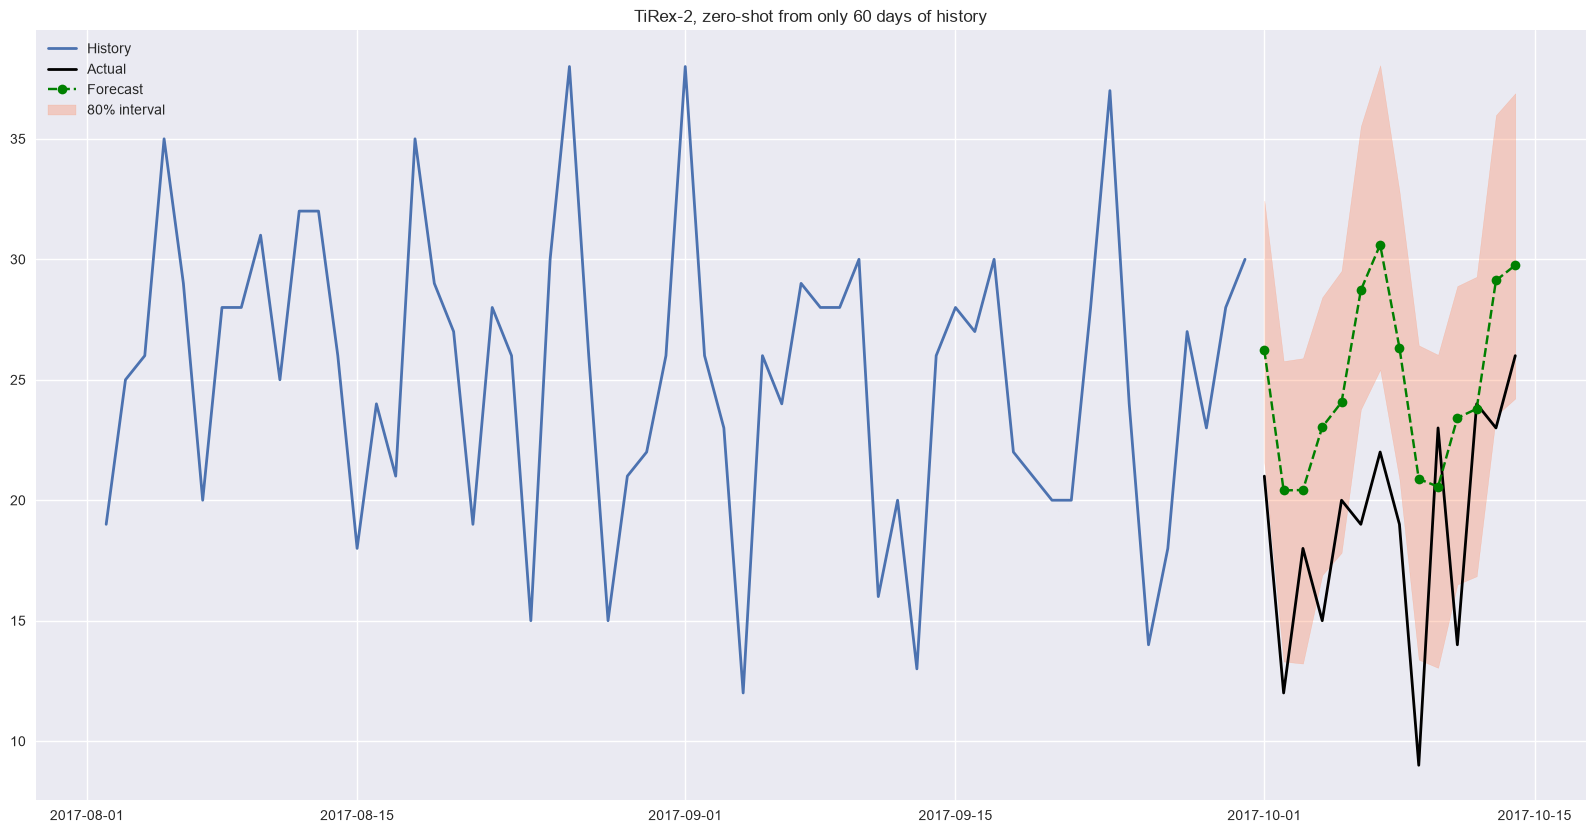

In [36]:
q_cold = tirex2_q_cold[0]
plot_forecast(CFG.HERO_ITEM, origin0, tirex2_point_cold[0],
              "TiRex-2, zero-shot from only 60 days of history",
              lower=q_cold[:, 0], upper=q_cold[:, 8],
              history_days=COLD_DAYS)

This code generates a visualization of the TiRex-2 forecast when trained on only 60 days of historical data.

It calls the `plot_forecast` function to create a plot displaying the historical context, actual values, and predicted forecast for the hero item at the first validation origin (`origin0`). The title indicates that the forecast is generated using TiRex-2 in a zero-shot manner with only 60 days of history.

The lower and upper bounds of the 80% prediction interval are defined by the 10th percentile (`q_cold[:, 0]`) and 90th percentile (`q_cold[:, 8]`) quantiles from the TiRex-2 forecast. The `history_days` parameter is set to `COLD_DAYS` (60) to display only the limited historical context used for training.

This visualization allows for a visual assessment of how well TiRex-2 performs when trained on a small amount of data, and it shows the uncertainty associated with the forecast through the prediction interval.